In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 13
plt.rcParams['axes.labelsize'] = 11

PROJECT_ROOT = Path('../../')
OUTPUTS_DIR = PROJECT_ROOT / 'outputs'
BASELINE_TAG = 'BASELINE_20250815T000000Z'

BASINS = ['calpella', 'guerneville', 'hopland', 'warm_springs']
RESOLUTIONS = ['daily', 'hourly', 'mts_daily', 'mts_hourly']
MODELS = ['HMS', 'LSTM', 'PILSTM']

In [2]:
def get_metrics_path(basin, res):
    base = OUTPUTS_DIR / basin / res / BASELINE_TAG / 'metrics' / 'test'
    if res in ('daily', 'hourly'):
        return base / f'{basin}_{res}_test_metrics.csv'
    freq = '1D' if res == 'mts_daily' else '1H'
    return base / f'{basin}_mts_test_metrics_{freq}.csv'

rows = []
for basin in BASINS:
    for res in RESOLUTIONS:
        path = get_metrics_path(basin, res)
        if not path.exists():
            print(f"MISSING: {path}")
            continue
        df = pd.read_csv(path, index_col=0)
        for metric in df.index:
            if metric == 'MSE':  # redundant with RMSE
                continue
            for model in MODELS:
                rows.append({'basin': basin, 'resolution': res, 'model': model,
                             'metric': metric, 'value': pd.to_numeric(df.loc[metric, model], errors='coerce')})

metrics_df = pd.DataFrame(rows)
print(f"Loaded {len(metrics_df)} entries | {metrics_df.basin.nunique()} basins | {metrics_df.resolution.nunique()} resolutions")
print(f"Metrics: {metrics_df.metric.unique().tolist()}")

Loaded 624 entries | 4 basins | 4 resolutions
Metrics: ['NSE', 'RMSE', 'KGE', 'Alpha-NSE', 'Beta-KGE', 'Beta-NSE', 'Pearson-r', 'FHV', 'FMS', 'FLV', 'Peak-Timing', 'Peak-MAPE', 'PBIAS']


In [3]:
metrics_df

,basin,resolution,model,metric,value
0,calpella,daily,HMS,NSE,0.699185
1,calpella,daily,LSTM,NSE,0.802015
2,calpella,daily,PILSTM,NSE,0.841130
3,calpella,daily,HMS,RMSE,276.787628
4,calpella,daily,LSTM,RMSE,224.550395
...,...,...,...,...,...
619,warm_springs,mts_hourly,LSTM,Peak-MAPE,43.085247
620,warm_springs,mts_hourly,PILSTM,Peak-MAPE,41.967430
621,warm_springs,mts_hourly,HMS,PBIAS,-3.797194
622,warm_springs,mts_hourly,LSTM,PBIAS,-6.051256


In [4]:
def pivot_basin(basin):
    df = metrics_df[metrics_df['basin'] == basin].pivot(index='metric', columns=['resolution', 'model'], values='value').round(3)
    df.columns = [f'{res}_{mod}' for res, mod in df.columns]
    return df

In [5]:
calpella_df = pivot_basin('calpella')
guerneville_df = pivot_basin('guerneville')
hopland_df = pivot_basin('hopland')
warm_springs_df = pivot_basin('warm_springs')

calpella_df

,daily_HMS,daily_LSTM,daily_PILSTM,hourly_HMS,hourly_LSTM,hourly_PILSTM,mts_daily_HMS,mts_daily_LSTM,mts_daily_PILSTM,mts_hourly_HMS,mts_hourly_LSTM,mts_hourly_PILSTM
metric,,,,,,,,,,,,
Alpha-NSE,1.225,0.750,0.876,1.198,0.583,0.908,1.223,0.611,0.854,1.198,0.696,0.853
Beta-KGE,1.059,0.920,0.924,1.060,0.886,1.004,1.060,1.031,0.973,1.060,0.890,1.019
Beta-NSE,0.035,-0.047,-0.045,0.030,-0.057,0.002,0.035,0.018,-0.016,0.030,-0.055,0.010
FHV,25.594,-23.218,-7.035,22.974,-37.195,1.036,25.179,-32.760,-9.974,22.974,-26.236,-6.936
FLV,-969.541,-78.330,54.654,1.652,86.005,-1.946,-969.891,91.333,56.934,1.652,-2.443,-3.487
FMS,0.630,-29.641,-12.444,0.436,-36.370,-16.841,0.135,-48.366,-22.139,0.436,-22.651,-19.444
KGE,0.746,0.723,0.833,0.762,0.542,0.828,0.748,0.594,0.832,0.762,0.652,0.799
NSE,0.699,0.802,0.841,0.678,0.648,0.728,0.703,0.712,0.844,0.678,0.726,0.748
PBIAS,-5.886,7.954,7.626,-6.037,11.418,-0.449,-5.952,-3.081,2.683,-6.037,10.978,-1.913


### Metrics Description Summary

#### Overall Performance

| Metric | Formula | Optimal | Interpretation |
|---|---|---|---|
| **NSE** | $1 - \frac{\sum(Q_{sim} - Q_{obs})^2}{\sum(Q_{obs} - \bar{Q}_{obs})^2}$ | 1 (higher = better) | How much better than predicting the mean. NSE=0 means no better than the mean; NSE<0 means worse. |
| **KGE** | $1 - \sqrt{s_r(r-1)^2 + s_\alpha(\alpha-1)^2 + s_\beta(\beta_{KGE}-1)^2}$ | 1 (higher = better) | Composite of correlation ($r$), variability ratio ($\alpha$), and bias ratio ($\beta$) with weights $s_r, s_\alpha, s_\beta$ (default 1,1,1). Addresses NSE's known shortcomings. |
| **Pearson-r** | $\frac{\sum(Q_{obs} - \bar{Q}_{obs})(Q_{sim} - \bar{Q}_{sim})}{\sigma_{obs} \cdot \sigma_{sim}}$ | 1 (higher = better) | Pure correlation — captures timing/shape. Ignores magnitude and bias (means are subtracted out). |
| **RMSE** | $\sqrt{\frac{1}{T}\sum(\hat{y}_t - y_t)^2}$ | 0 (lower = better) | Average error magnitude in flow units (cfs). Penalizes large errors heavily. |

#### Bias Metrics

| Metric | Formula | Optimal | Interpretation |
|---|---|---|---|
| **PBIAS** | $\frac{\sum(Q_{sim} - Q_{obs})}{\sum Q_{obs}} \times 100$ | 0 (closer to 0) | Percent volume bias. Positive = overprediction, negative = underprediction. |
| **Beta-NSE** | $\frac{\mu_{sim} - \mu_{obs}}{\sigma_{obs}}$ | 0 (closer to 0) | Normalized bias. Same concept as PBIAS but scaled by observed variability. |
| **Beta-KGE** | $\frac{\mu_{sim}}{\mu_{obs}}$ | 1 (closer to 1) | Mean ratio. >1 = overprediction, <1 = underprediction. |
| **Alpha-NSE** | $\frac{\sigma_{sim}}{\sigma_{obs}}$ | 1 (closer to 1) | Variability ratio. >1 = model too flashy, <1 = model too smooth/damped. |

#### Flow Duration Curve (FDC) Metrics

| Metric | What it Captures | Optimal | Interpretation |
|---|---|---|---|
| **FHV** | Bias in **top 2%** of flows | 0% (closer to 0) | Peak/flood volume error. Positive = overpredicting peaks, negative = underpredicting. |
| **FMS** | Slope error in **20th-70th percentile** | 0% (closer to 0) | Mid-range flow distribution error. |
| **FLV** | Bias in **bottom 30%** of flows (log-transformed) | 0% (closer to 0) | Low flow / baseflow error. Log transform so small values matter. |

#### Peak Metrics

| Metric | Formula | Optimal | Interpretation |
|---|---|---|---|
| **Peak-Timing** | Mean abs time difference between obs/sim peaks | 0 (lower = better) | How well peaks are aligned in time (days or hours). |
| **Peak-MAPE** | $\frac{1}{P}\sum\left\|\frac{Q_{s,p} - Q_{o,p}}{Q_{o,p}}\right\| \times 100$ | 0% (lower = better) | Mean absolute percentage error of peak magnitudes. |

#### Color Direction for Heatmaps

| Category | Metrics | Color Logic |
|---|---|---|
| Higher = better | NSE, KGE, Pearson-r | z-score as-is |
| Lower = better | RMSE, Peak-Timing, Peak-MAPE | negate z-score |
| Closer to 0 = better | PBIAS, Beta-NSE, FHV, FMS, FLV | z-score of $-|value|$ |
| Closer to 1 = better | Alpha-NSE, Beta-KGE | z-score of $-|value - 1|$ |

In [6]:
HIGHER_IS_BETTER = ['NSE', 'KGE', 'Pearson-r']
LOWER_IS_BETTER = ['RMSE', 'Peak-Timing', 'Peak-MAPE']
CLOSER_TO_ZERO = ['PBIAS', 'Beta-NSE', 'FHV', 'FMS', 'FLV']
CLOSER_TO_ONE = ['Alpha-NSE', 'Beta-KGE']

METRIC_ORDER = HIGHER_IS_BETTER + CLOSER_TO_ONE + LOWER_IS_BETTER + CLOSER_TO_ZERO

In [7]:
def transform_for_color(df):
    t = df.copy()
    for m in LOWER_IS_BETTER:
        if m in t.index: t.loc[m] = -t.loc[m]
    for m in CLOSER_TO_ZERO:
        if m in t.index: t.loc[m] = -t.loc[m].abs()
    for m in CLOSER_TO_ONE:
        if m in t.index: t.loc[m] = -(t.loc[m] - 1).abs()
    return t

In [8]:
def ranking_summary(basin_df, basin, freq='daily'):
    if freq == 'daily':
        cols = {'HMS': 'daily_HMS', 'LSTM': 'daily_LSTM', 'PILSTM': 'daily_PILSTM', 'MTS_LSTM': 'mts_daily_LSTM', 'MTS_PILSTM': 'mts_daily_PILSTM'}
    else:
        cols = {'HMS': 'hourly_HMS', 'LSTM': 'hourly_LSTM', 'PILSTM': 'hourly_PILSTM', 'MTS_LSTM': 'mts_hourly_LSTM', 'MTS_PILSTM': 'mts_hourly_PILSTM'}
    subset = basin_df[list(cols.values())].copy()
    subset.columns = list(cols.keys())
    ordered = subset.reindex([m for m in METRIC_ORDER if m in subset.index])
    transformed = transform_for_color(ordered)
    winners = transformed.idxmax(axis=1)
    print(f"{basin.upper()} ({freq})")
    for model in cols.keys():
        won = winners[winners == model].index.tolist()
        if won:
            print(f"{model} - {len(won)} wins - {won}")

In [ ]:
FIGURES_DIR = Path('metrics_analysis/figures')
for sub in ['heatmaps', 'bar_charts', 'scatterplots', 'fdcs', 'hydrographs']:
    (FIGURES_DIR / sub).mkdir(parents=True, exist_ok=True)

def normalized_heatmap(basin_df, basin, freq='daily', figsize=(12, 8)):
    if freq == 'daily':
        cols = {'HMS': 'daily_HMS', 'LSTM': 'daily_LSTM', 'PILSTM': 'daily_PILSTM',
                'MTS_LSTM': 'mts_daily_LSTM', 'MTS_PILSTM': 'mts_daily_PILSTM'}
    else:
        cols = {'HMS': 'hourly_HMS', 'LSTM': 'hourly_LSTM', 'PILSTM': 'hourly_PILSTM',
                'MTS_LSTM': 'mts_hourly_LSTM', 'MTS_PILSTM': 'mts_hourly_PILSTM'}
    subset = basin_df[list(cols.values())].copy()
    subset.columns = list(cols.keys())
    ordered = subset.reindex([m for m in METRIC_ORDER if m in subset.index])
    transformed = transform_for_color(ordered)
    z = transformed.apply(lambda row: (row - row.mean()) / row.std(), axis=1)
    fig, ax = plt.subplots(figsize=figsize)
    sns.heatmap(z, annot=ordered.values, fmt='.2f', cmap='RdYlGn', center=0,
                ax=ax, cbar=False, annot_kws={'size': 10})
    ax.set_title(f"{basin.replace('_', ' ').title()} ({freq})")
    ax.set_ylabel('')
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'heatmaps' / f'{basin}_{freq}_heatmap.png', dpi=300, bbox_inches='tight')
    plt.show()

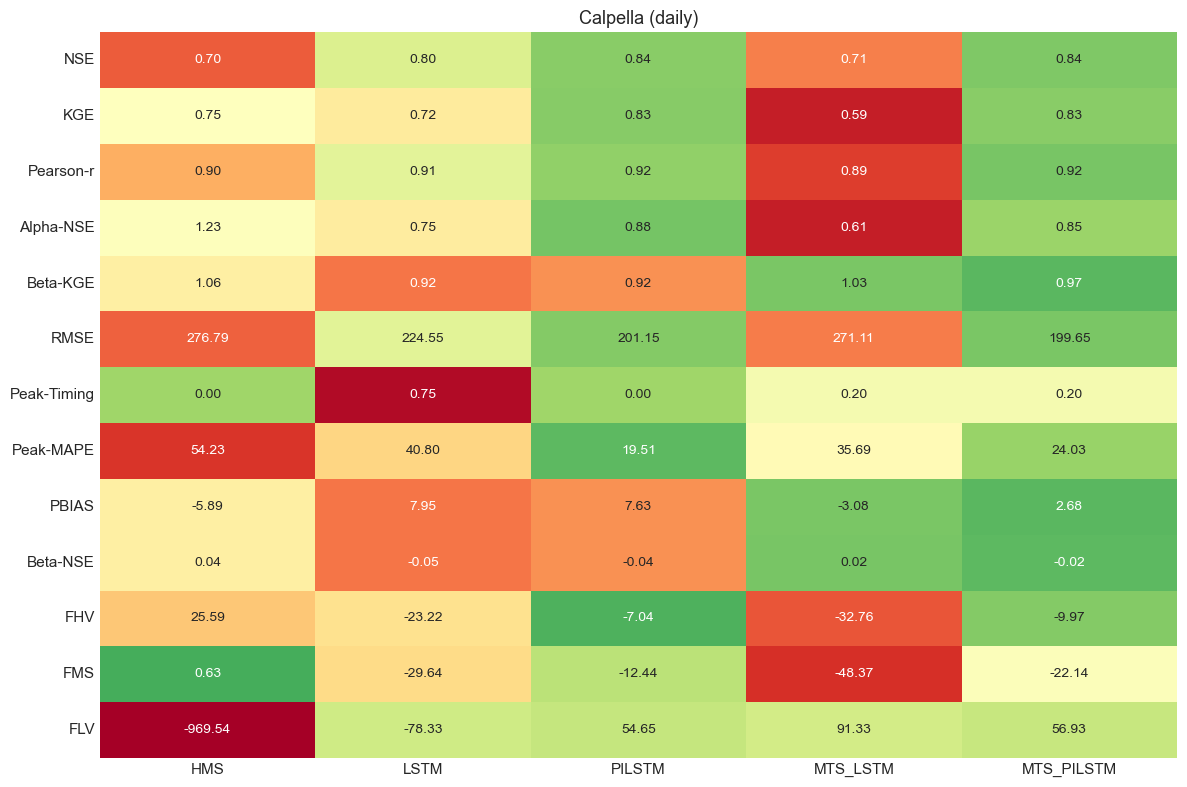

In [10]:
normalized_heatmap(calpella_df, 'calpella', 'daily')

In [11]:
ranking_summary(calpella_df, 'calpella', freq='daily')

CALPELLA (daily)
HMS - 2 wins - ['Peak-Timing', 'FMS']
PILSTM - 5 wins - ['KGE', 'Alpha-NSE', 'Peak-MAPE', 'FHV', 'FLV']
MTS_PILSTM - 6 wins - ['NSE', 'Pearson-r', 'Beta-KGE', 'RMSE', 'PBIAS', 'Beta-NSE']


### Calpella Daily Observations

#### MTS_PILSTM and PILSTM performs the best overall (6 and 5 wins) - physics is helping
##### - ...

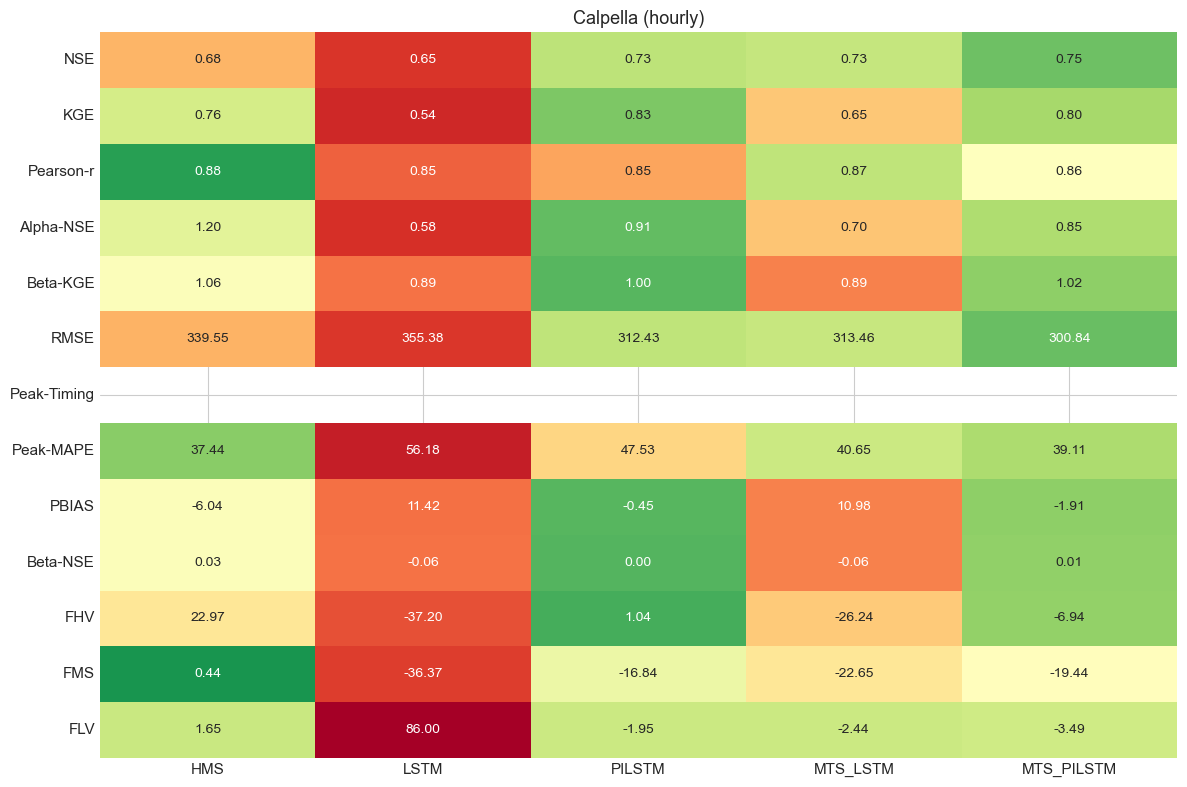

In [12]:
normalized_heatmap(calpella_df, 'calpella', 'hourly')

In [13]:
ranking_summary(calpella_df, 'calpella', freq='hourly')

CALPELLA (hourly)
HMS - 4 wins - ['Pearson-r', 'Peak-MAPE', 'FMS', 'FLV']
PILSTM - 6 wins - ['KGE', 'Alpha-NSE', 'Beta-KGE', 'PBIAS', 'Beta-NSE', 'FHV']
MTS_PILSTM - 2 wins - ['NSE', 'RMSE']


### Calpella Hourly Observations

##### Standalone PILSTM has the most "wins" - normal since it's fed pure hourly data? Performing well with the bias metrics - physics correcting model 

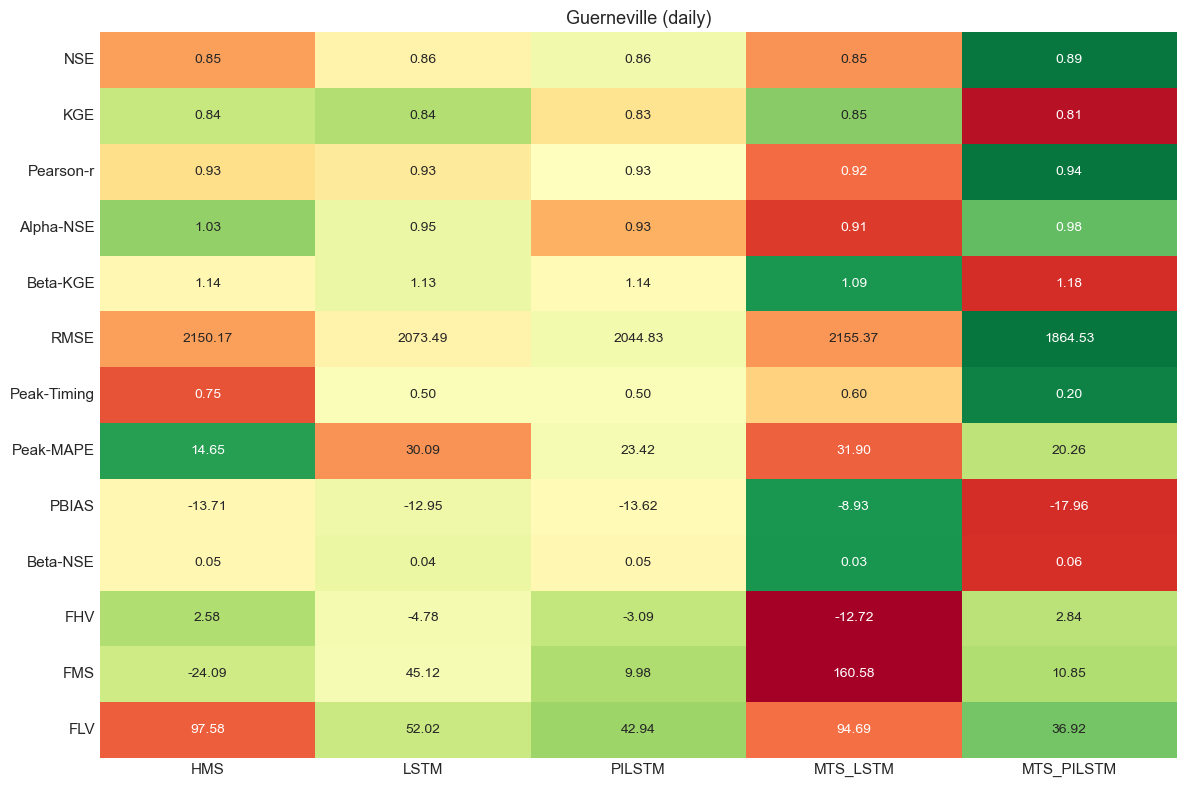

In [14]:
normalized_heatmap(guerneville_df, 'guerneville', 'daily')

In [15]:
ranking_summary(guerneville_df, 'guerneville', freq='daily')

GUERNEVILLE (daily)
HMS - 2 wins - ['Peak-MAPE', 'FHV']
PILSTM - 1 wins - ['FMS']
MTS_LSTM - 4 wins - ['KGE', 'Beta-KGE', 'PBIAS', 'Beta-NSE']
MTS_PILSTM - 6 wins - ['NSE', 'Pearson-r', 'Alpha-NSE', 'RMSE', 'Peak-Timing', 'FLV']


### Guerneville Daily Observations

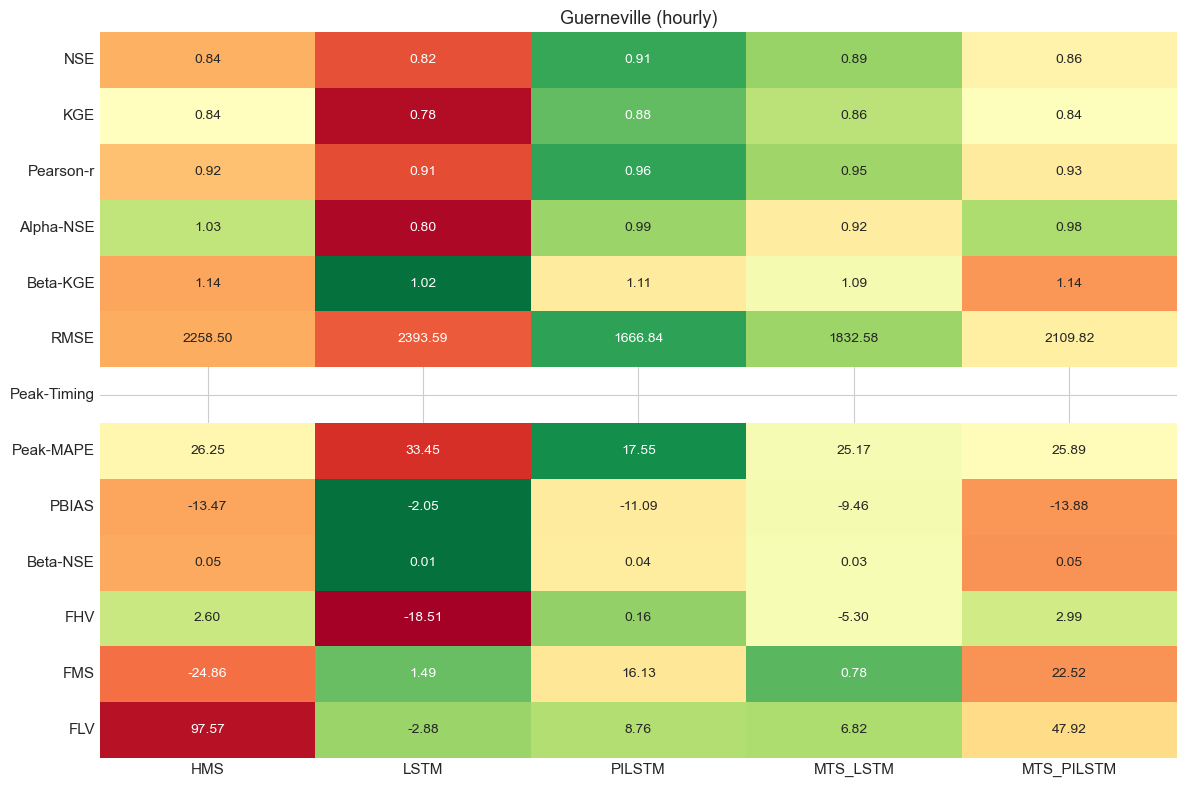

In [16]:
normalized_heatmap(guerneville_df, 'guerneville', 'hourly')

In [17]:
ranking_summary(guerneville_df, 'guerneville', freq='hourly')

GUERNEVILLE (hourly)
LSTM - 4 wins - ['Beta-KGE', 'PBIAS', 'Beta-NSE', 'FLV']
PILSTM - 7 wins - ['NSE', 'KGE', 'Pearson-r', 'Alpha-NSE', 'RMSE', 'Peak-MAPE', 'FHV']
MTS_LSTM - 1 wins - ['FMS']


### Guerneville Hourly Observations

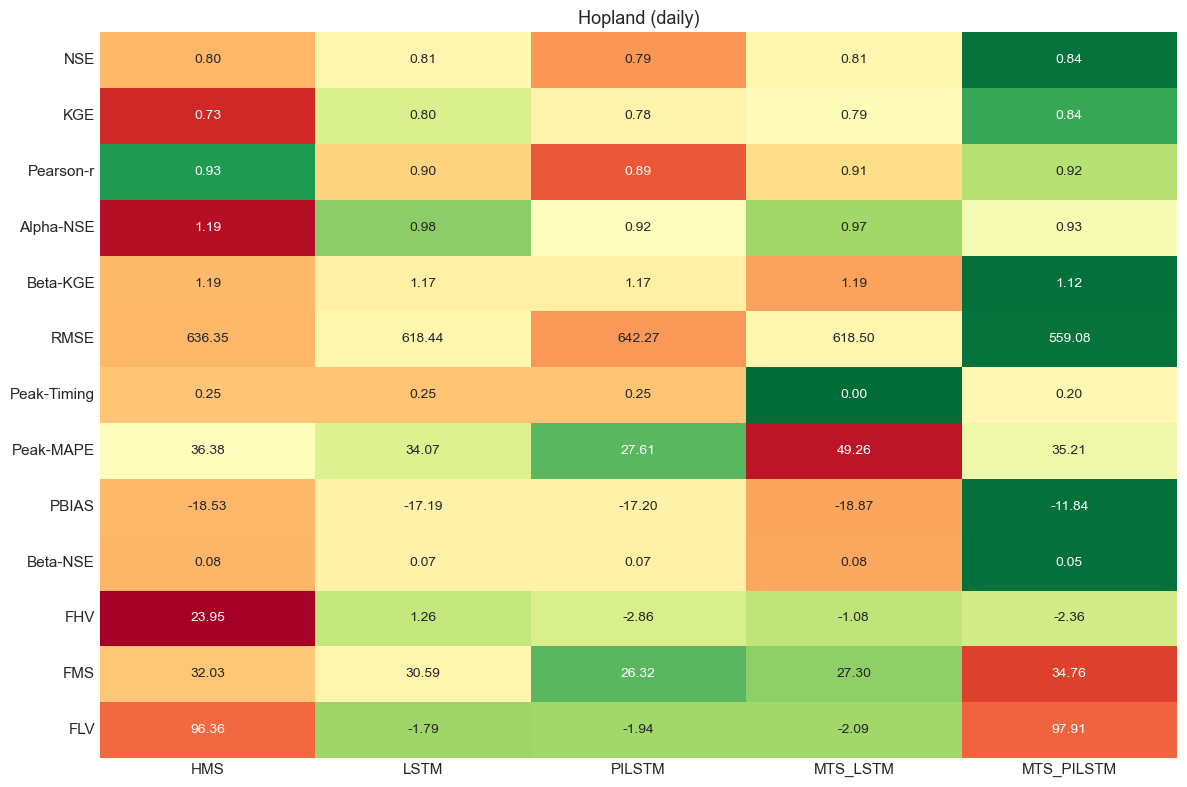

In [18]:
normalized_heatmap(hopland_df, 'hopland', 'daily')

In [19]:
ranking_summary(hopland_df, 'hopland', freq='daily')

HOPLAND (daily)
HMS - 1 wins - ['Pearson-r']
LSTM - 2 wins - ['Alpha-NSE', 'FLV']
PILSTM - 2 wins - ['Peak-MAPE', 'FMS']
MTS_LSTM - 2 wins - ['Peak-Timing', 'FHV']
MTS_PILSTM - 6 wins - ['NSE', 'KGE', 'Beta-KGE', 'RMSE', 'PBIAS', 'Beta-NSE']


### Hopland Daily Observations

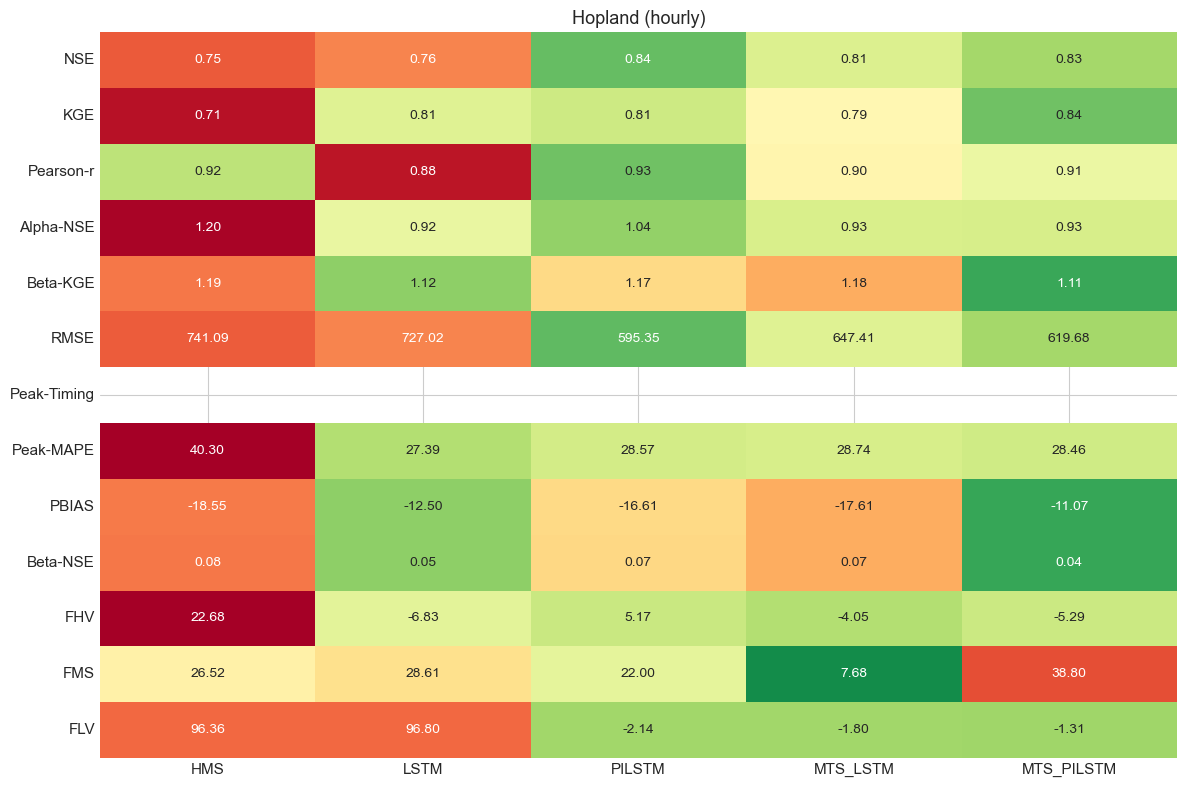

In [20]:
normalized_heatmap(hopland_df, 'hopland', 'hourly')

In [21]:
ranking_summary(hopland_df, 'hopland', freq='hourly')

HOPLAND (hourly)
LSTM - 1 wins - ['Peak-MAPE']
PILSTM - 4 wins - ['NSE', 'Pearson-r', 'Alpha-NSE', 'RMSE']
MTS_LSTM - 2 wins - ['FHV', 'FMS']
MTS_PILSTM - 5 wins - ['KGE', 'Beta-KGE', 'PBIAS', 'Beta-NSE', 'FLV']


### Hopland Hourly Observations

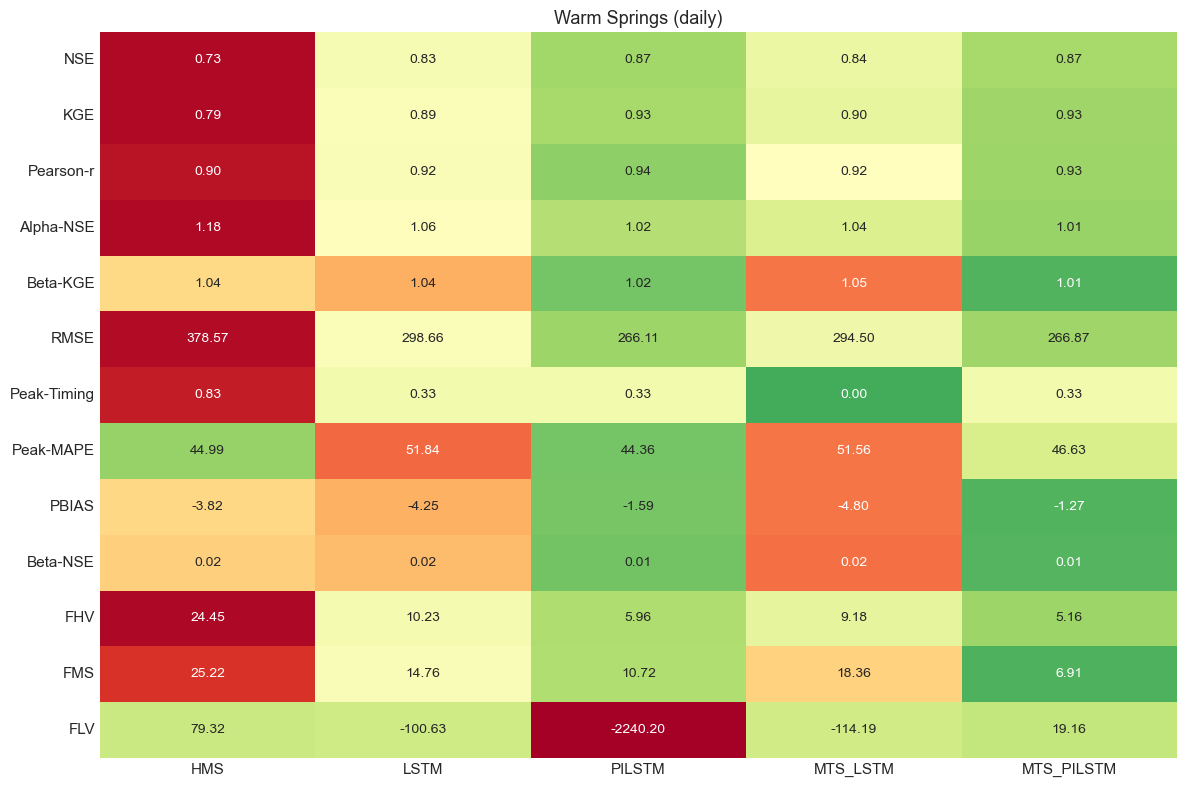

In [22]:
normalized_heatmap(warm_springs_df, 'warm_springs', 'daily')

In [23]:
ranking_summary(warm_springs_df, 'warm_springs', freq='daily')

WARM_SPRINGS (daily)
PILSTM - 4 wins - ['NSE', 'Pearson-r', 'RMSE', 'Peak-MAPE']
MTS_LSTM - 1 wins - ['Peak-Timing']
MTS_PILSTM - 8 wins - ['KGE', 'Alpha-NSE', 'Beta-KGE', 'PBIAS', 'Beta-NSE', 'FHV', 'FMS', 'FLV']


### Warm Springs Daily Observations

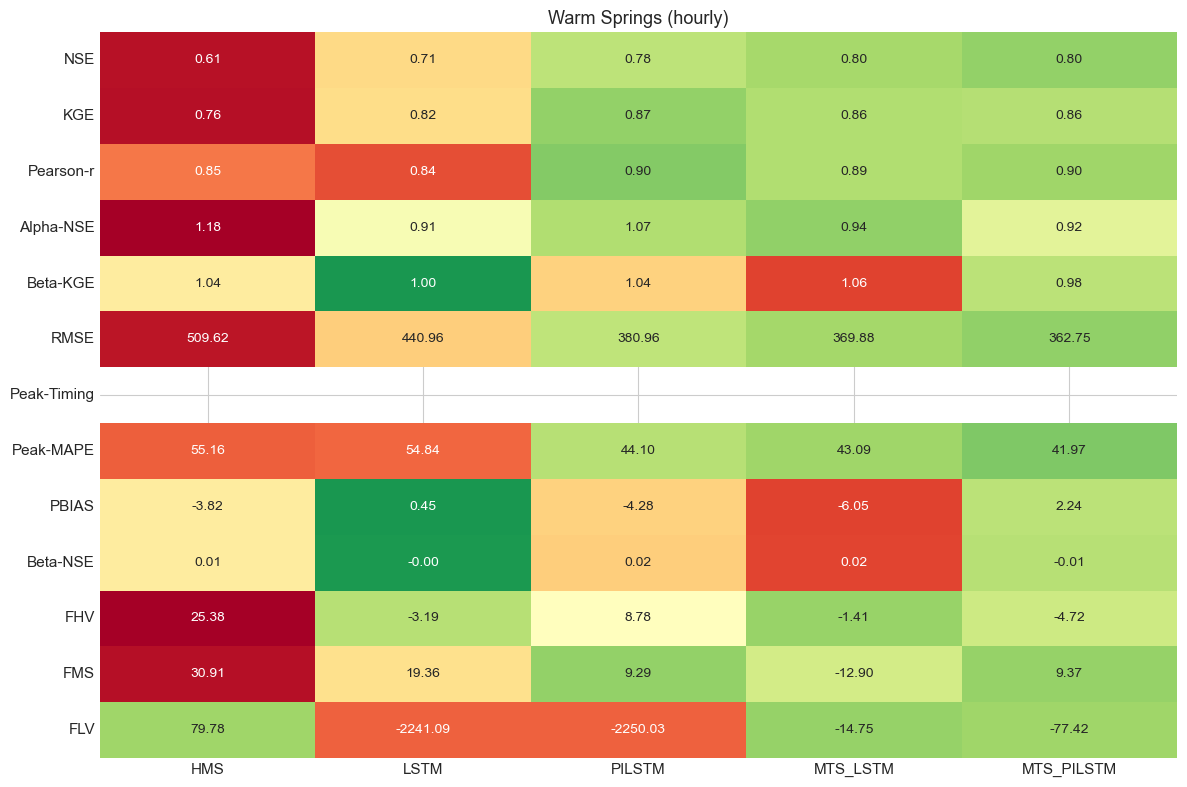

In [24]:
normalized_heatmap(warm_springs_df, 'warm_springs', 'hourly')

In [25]:
ranking_summary(warm_springs_df, 'warm_springs', freq='hourly')

WARM_SPRINGS (hourly)
LSTM - 3 wins - ['Beta-KGE', 'PBIAS', 'Beta-NSE']
PILSTM - 3 wins - ['KGE', 'Pearson-r', 'FMS']
MTS_LSTM - 3 wins - ['Alpha-NSE', 'FHV', 'FLV']
MTS_PILSTM - 3 wins - ['NSE', 'RMSE', 'Peak-MAPE']


### Warm Springs Hourly Observations

### Some Overall Trends

In [26]:
COLS_MAP = {
    'daily': {'HMS': 'daily_HMS', 'LSTM': 'daily_LSTM', 'PILSTM': 'daily_PILSTM', 'MTS_LSTM': 'mts_daily_LSTM', 'MTS_PILSTM': 'mts_daily_PILSTM'},
    'hourly': {'HMS': 'hourly_HMS', 'LSTM': 'hourly_LSTM', 'PILSTM': 'hourly_PILSTM', 'MTS_LSTM': 'mts_hourly_LSTM', 'MTS_PILSTM': 'mts_hourly_PILSTM'}}

def get_winners(basin_df, freq):
    cols = COLS_MAP[freq]
    subset = basin_df[list(cols.values())].copy()
    subset.columns = list(cols.keys())
    ordered = subset.reindex([m for m in METRIC_ORDER if m in subset.index])
    transformed = transform_for_color(ordered)
    return transformed.idxmax(axis=1)

In [27]:
all_winners = []
basin_dfs = {'calpella': calpella_df, 'guerneville': guerneville_df,
             'hopland': hopland_df, 'warm_springs': warm_springs_df}
for basin, df in basin_dfs.items():
    for freq in ['daily', 'hourly']:
        winners = get_winners(df, freq)
        for metric, model in winners.items():
            all_winners.append({'basin': basin, 'freq': freq, 'metric': metric, 'winner': model})

winners_df = pd.DataFrame(all_winners)

In [28]:
winners_df

,basin,freq,metric,winner
0,calpella,daily,NSE,MTS_PILSTM
1,calpella,daily,KGE,PILSTM
2,calpella,daily,Pearson-r,MTS_PILSTM
3,calpella,daily,Alpha-NSE,PILSTM
4,calpella,daily,Beta-KGE,MTS_PILSTM
...,...,...,...,...
99,warm_springs,hourly,PBIAS,LSTM
100,warm_springs,hourly,Beta-NSE,LSTM
101,warm_springs,hourly,FHV,MTS_LSTM
102,warm_springs,hourly,FMS,PILSTM


In [29]:
print("TOTAL WINS BY MODEL:")
print(winners_df['winner'].value_counts().to_string())

print("\nWINS BY MODEL AND FREQUENCY:")
print(winners_df.groupby(['freq', 'winner']).size().unstack(fill_value=0).to_string())

TOTAL WINS BY MODEL:
winner
MTS_PILSTM    36
PILSTM        32
MTS_LSTM      13
LSTM          10
HMS            9

WINS BY MODEL AND FREQUENCY:
winner  HMS  LSTM  MTS_LSTM  MTS_PILSTM  PILSTM
freq                                           
daily     5     2         7          26      12
hourly    4     8         6          10      20


In [30]:
print("MOST FREQUENT WINNER PER METRIC (across 8 basin-freq combos)")
for metric in METRIC_ORDER:
    sub = winners_df[winners_df['metric'] == metric]
    if len(sub) == 0:
        continue
    counts = sub['winner'].value_counts()
    print(f"  {metric}: {counts.to_dict()}")

MOST FREQUENT WINNER PER METRIC (across 8 basin-freq combos)
  NSE: {'MTS_PILSTM': 5, 'PILSTM': 3}
  KGE: {'PILSTM': 4, 'MTS_PILSTM': 3, 'MTS_LSTM': 1}
  Pearson-r: {'PILSTM': 4, 'MTS_PILSTM': 2, 'HMS': 2}
  Alpha-NSE: {'PILSTM': 4, 'MTS_PILSTM': 2, 'LSTM': 1, 'MTS_LSTM': 1}
  Beta-KGE: {'MTS_PILSTM': 4, 'LSTM': 2, 'PILSTM': 1, 'MTS_LSTM': 1}
  RMSE: {'MTS_PILSTM': 5, 'PILSTM': 3}
  Peak-Timing: {'MTS_LSTM': 2, 'HMS': 1, 'MTS_PILSTM': 1}
  Peak-MAPE: {'PILSTM': 4, 'HMS': 2, 'LSTM': 1, 'MTS_PILSTM': 1}
  PBIAS: {'MTS_PILSTM': 4, 'LSTM': 2, 'PILSTM': 1, 'MTS_LSTM': 1}
  Beta-NSE: {'MTS_PILSTM': 4, 'LSTM': 2, 'PILSTM': 1, 'MTS_LSTM': 1}
  FHV: {'PILSTM': 3, 'MTS_LSTM': 3, 'HMS': 1, 'MTS_PILSTM': 1}
  FMS: {'PILSTM': 3, 'HMS': 2, 'MTS_LSTM': 2, 'MTS_PILSTM': 1}
  FLV: {'MTS_PILSTM': 3, 'LSTM': 2, 'PILSTM': 1, 'HMS': 1, 'MTS_LSTM': 1}


In [31]:
winners_df['has_physics'] = winners_df['winner'].isin(['PILSTM', 'MTS_PILSTM'])
physics_by_freq = winners_df.groupby(['freq', 'has_physics']).size().unstack(fill_value=0)
physics_by_freq.columns = ['No Physics', 'Physics']
print("PHYSICS vs NON-PHYSICS BY FREQUENCY")
print(physics_by_freq.to_string())
print(f"\nOverall: Physics {winners_df['has_physics'].sum()} / {len(winners_df)} ({winners_df['has_physics'].mean()*100:.0f}%)")

PHYSICS vs NON-PHYSICS BY FREQUENCY
        No Physics  Physics
freq                       
daily           14       38
hourly          22       30

Overall: Physics 68 / 104 (65%)


In [32]:
winners_ml = winners_df[winners_df['winner'] != 'HMS'].copy()
winners_ml['is_mts'] = winners_ml['winner'].str.startswith('MTS')
mts_by_freq = winners_ml.groupby(['freq', 'is_mts']).size().unstack(fill_value=0)
mts_by_freq.columns = ['Standalone', 'MTS']
print("MTS vs STANDALONE (ML models only)")
print(mts_by_freq.to_string())

MTS vs STANDALONE (ML models only)
        Standalone  MTS
freq                   
daily           14   33
hourly          28   16


In [33]:
print("WINS BY BASIN AND MODEL")
print(winners_df.groupby(['basin', 'winner']).size().unstack(fill_value=0).to_string())

WINS BY BASIN AND MODEL
winner        HMS  LSTM  MTS_LSTM  MTS_PILSTM  PILSTM
basin                                                
calpella        6     0         0           8      11
guerneville     2     4         5           6       8
hopland         1     3         4          11       6
warm_springs    0     3         4          11       7


In [34]:
print("HMS WINS DETAIL")
hms_wins = winners_df[winners_df['winner'] == 'HMS']
if len(hms_wins) > 0:
    print(f"Total: {len(hms_wins)}")
    print(f"Metrics won: {hms_wins['metric'].value_counts().to_dict()}")
    print(f"By basin: {hms_wins['basin'].value_counts().to_dict()}")
    print(f"By freq: {hms_wins['freq'].value_counts().to_dict()}")

HMS WINS DETAIL
Total: 9
Metrics won: {'FMS': 2, 'Pearson-r': 2, 'Peak-MAPE': 2, 'Peak-Timing': 1, 'FLV': 1, 'FHV': 1}
By basin: {'calpella': 6, 'guerneville': 2, 'hopland': 1}
By freq: {'daily': 5, 'hourly': 4}


### Overall Trend Findings

### Margin Analysis

In [49]:
def compute_margins(basin_df, freq):
    cols = COLS_MAP[freq]
    subset = basin_df[list(cols.values())].copy()
    subset.columns = list(cols.keys())
    ordered = subset.reindex([m for m in METRIC_ORDER if m in subset.index])
    transformed = transform_for_color(ordered)
    rows = []
    for metric in transformed.index:
        vals = transformed.loc[metric].sort_values(ascending=False)
        spread = vals.iloc[0] - vals.iloc[-1]
        pct = ((vals.iloc[0] - vals.iloc[1]) / spread * 100) if spread > 0 else 0
        rows.append({'metric': metric, 'winner': vals.index[0], 'runner_up': vals.index[1], 'pct_margin': round(pct, 1)})
    return pd.DataFrame(rows).set_index('metric')

for basin in BASINS:
    for freq in ['daily', 'hourly']:
        m = compute_margins(basin_dfs[basin], freq)
        close = m[m['pct_margin'] < 20]
        decisive = m[m['pct_margin'] > 50]
        print(f"{basin.upper()} ({freq})")
        print(m.to_string())
        if len(decisive) > 0:
            print(f"\nDecisive wins (>50%): {decisive.index.tolist()}")
        if len(close) > 0:
            print(f"Close calls (<20%): {close.index.tolist()}")

CALPELLA (daily)
                 winner   runner_up  pct_margin
metric                                         
NSE          MTS_PILSTM      PILSTM         2.1
KGE              PILSTM  MTS_PILSTM         0.4
Pearson-r    MTS_PILSTM      PILSTM         6.2
Alpha-NSE        PILSTM  MTS_PILSTM         8.3
Beta-KGE     MTS_PILSTM    MTS_LSTM         7.5
RMSE         MTS_PILSTM      PILSTM         1.9
Peak-Timing         HMS      PILSTM         0.0
Peak-MAPE        PILSTM  MTS_PILSTM        13.0
PBIAS        MTS_PILSTM    MTS_LSTM         7.6
Beta-NSE     MTS_PILSTM    MTS_LSTM         6.5
FHV              PILSTM  MTS_PILSTM        11.4
FMS                 HMS      PILSTM        24.7
FLV              PILSTM  MTS_PILSTM         0.2
Close calls (<20%): ['NSE', 'KGE', 'Pearson-r', 'Alpha-NSE', 'Beta-KGE', 'RMSE', 'Peak-Timing', 'Peak-MAPE', 'PBIAS', 'Beta-NSE', 'FHV', 'FLV']
CALPELLA (hourly)
                 winner   runner_up  pct_margin
metric                                         
NSE  

### Timeseries Analysis

In [50]:
def get_ts_path(basin, res):
    base = OUTPUTS_DIR / basin / res / BASELINE_TAG / 'timeseries' / 'test'
    if res == 'daily': return base / f'{basin}_daily_test_combined_ts.csv'
    if res == 'hourly': return base / f'{basin}_hourly_test_combined_ts.csv'
    if res == 'mts_daily': return base / f'{basin}_mts_test_1D_combined_ts.csv'
    return base / f'{basin}_mts_test_1H_combined_ts.csv'

def load_ts(basin, res):
    df = pd.read_csv(get_ts_path(basin, res), parse_dates=['Date'], index_col='Date')
    df.columns = ['Observed', 'HMS', 'LSTM', 'PILSTM']
    return df

def load_all_models(basin, freq='daily'):
    stand_res, mts_res = ('daily', 'mts_daily') if freq == 'daily' else ('hourly', 'mts_hourly')
    stand, mts = load_ts(basin, stand_res), load_ts(basin, mts_res)
    result = stand[['Observed', 'HMS', 'LSTM', 'PILSTM']].copy()
    result['MTS_LSTM'] = mts['LSTM']
    result['MTS_PILSTM'] = mts['PILSTM']
    return result

MODEL_COLORS = {'HMS': '#1f77b4', 'LSTM': '#ff7f0e', 'PILSTM': '#2ca02c', 'MTS_LSTM': '#d62728', 'MTS_PILSTM': '#9467bd'}
ALL_MODELS = ['HMS', 'LSTM', 'PILSTM', 'MTS_LSTM', 'MTS_PILSTM']

#### Observed vs Predicted Scatterplots

In [38]:
def scatter_obs_vs_pred(basin, freq='daily', figsize=(20, 4)):
    df = load_all_models(basin, freq)
    all_vals = pd.concat([df['Observed']] + [df[m] for m in ALL_MODELS]).dropna()
    lim = all_vals.quantile(0.995) * 1.05
    alpha = 0.3 if freq == 'daily' else 0.1
    s = 8 if freq == 'daily' else 2
    fig, axes = plt.subplots(1, 5, figsize=figsize)
    for ax, model in zip(axes, ALL_MODELS):
        valid = df[['Observed', model]].dropna()
        obs, pred = valid['Observed'], valid[model]
        ax.scatter(obs, pred, alpha=alpha, s=s, color=MODEL_COLORS[model])
        ax.plot([0, lim], [0, lim], 'k--', lw=0.8, alpha=0.5)
        ax.set_xlim(0, lim); ax.set_ylim(0, lim)
        ax.set_xlabel('Observed'); ax.set_ylabel('Predicted')
        r = obs.corr(pred)
        n_clipped = ((obs > lim) | (pred > lim)).sum()
        title = f'{model}  r={r:.3f}'
        if n_clipped > 0: title += f'  ({n_clipped} clipped)'
        ax.set_title(title, fontsize=10)
        ax.set_aspect('equal')
    fig.suptitle(f'{basin.replace("_", " ").title()} ({freq})', fontsize=14)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'scatterplots' / f'{basin}_{freq}_scatter.png', dpi=300, bbox_inches='tight')
    plt.show()

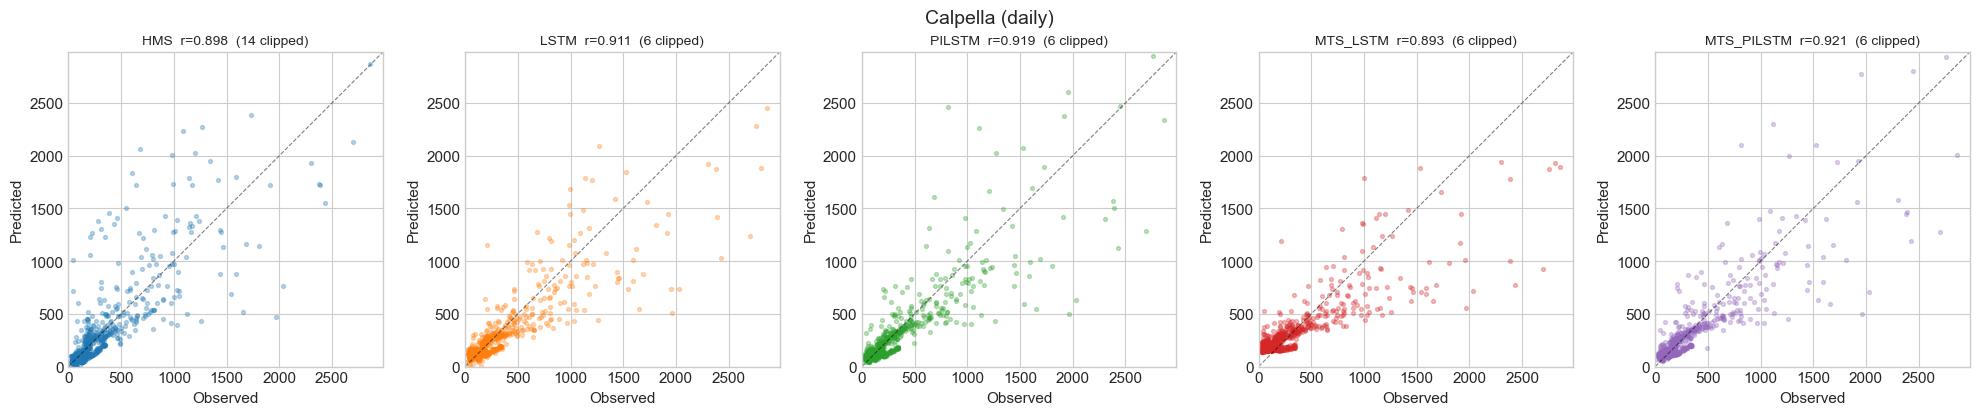

In [39]:
scatter_obs_vs_pred('calpella', 'daily')

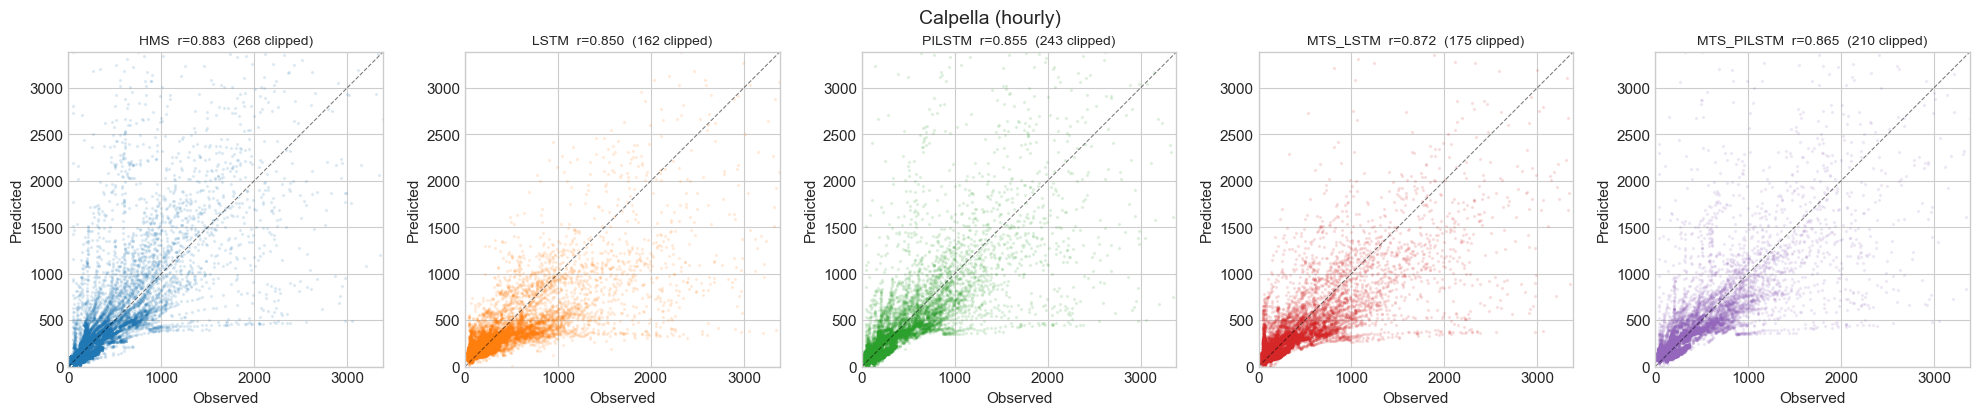

In [40]:
scatter_obs_vs_pred('calpella', 'hourly')

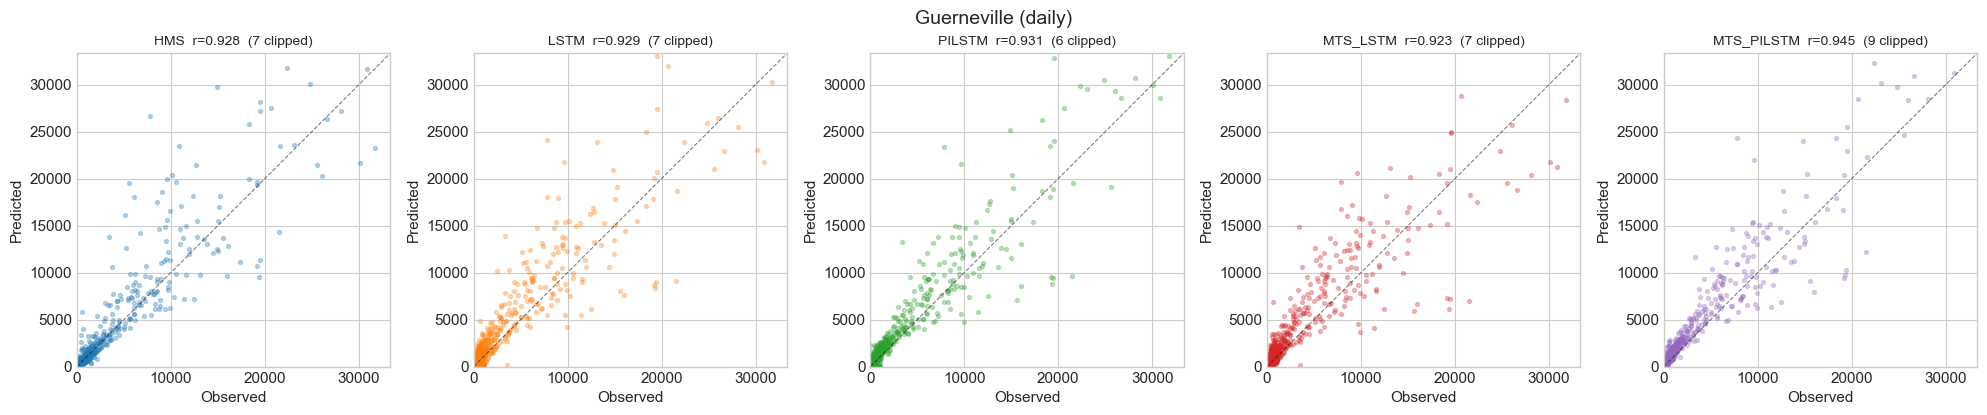

In [41]:
scatter_obs_vs_pred('guerneville', 'daily')

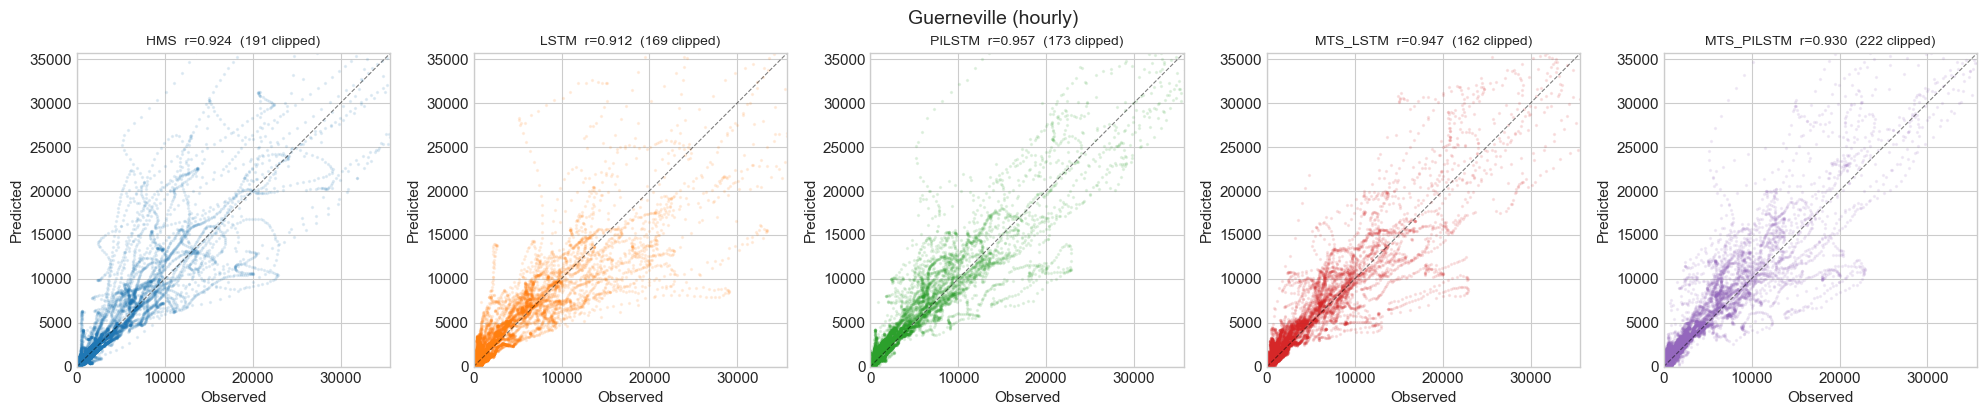

In [42]:
scatter_obs_vs_pred('guerneville', 'hourly')

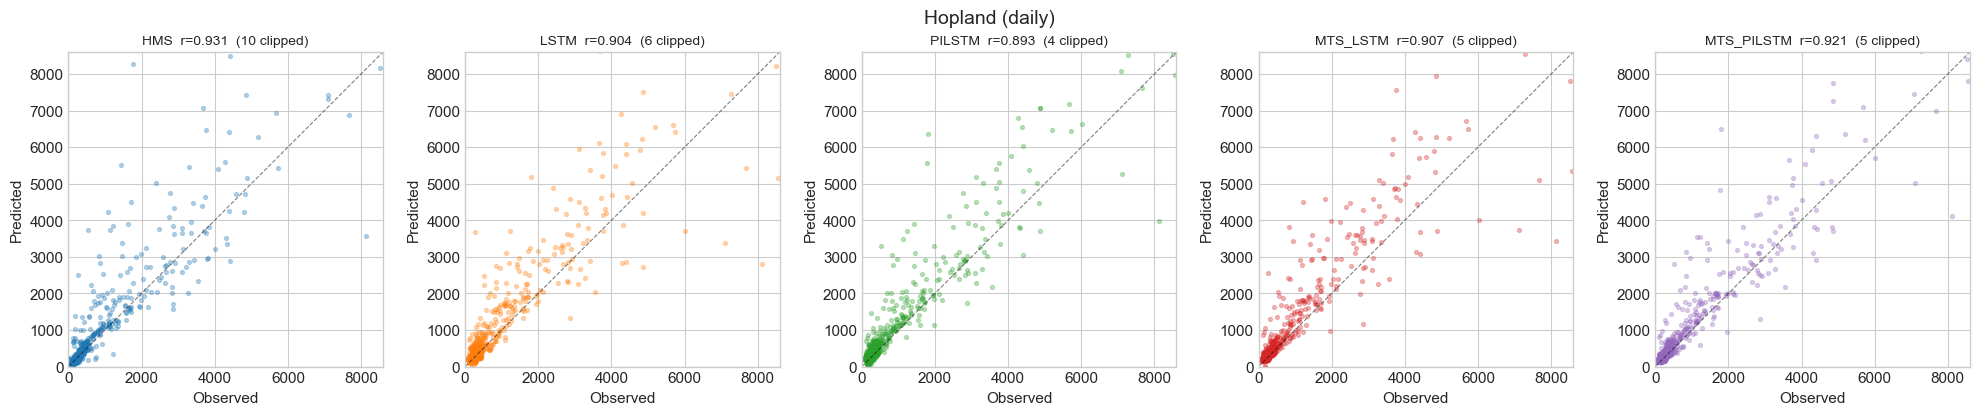

In [43]:
scatter_obs_vs_pred('hopland', 'daily')

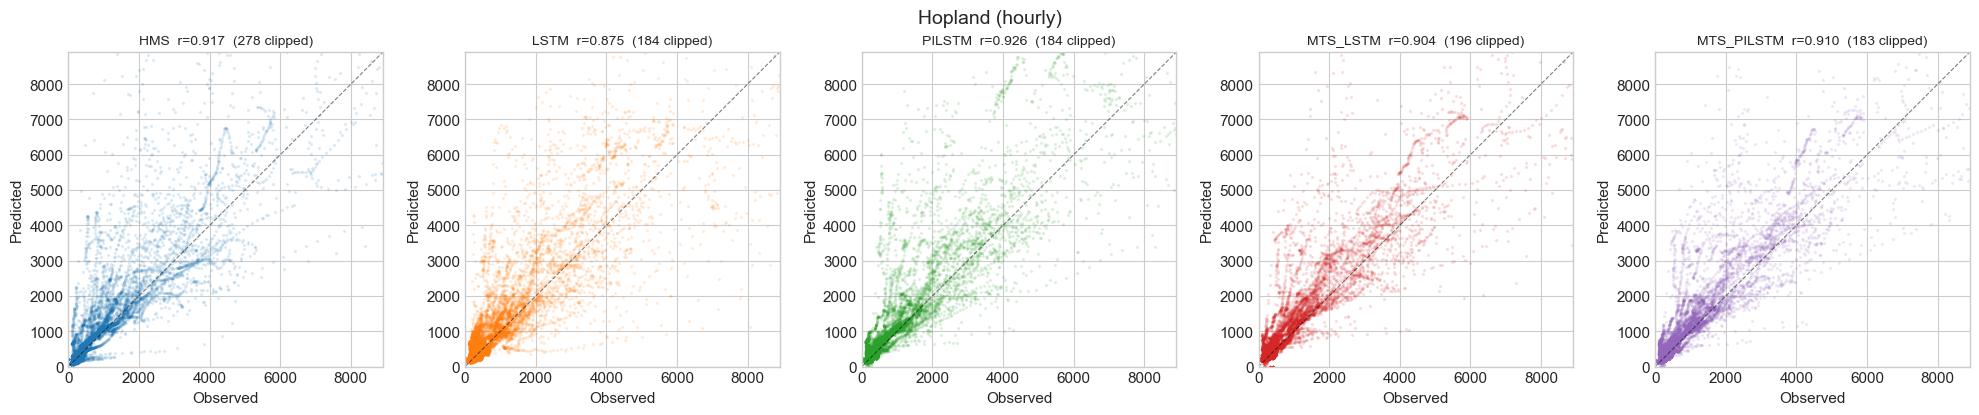

In [44]:
scatter_obs_vs_pred('hopland', 'hourly')

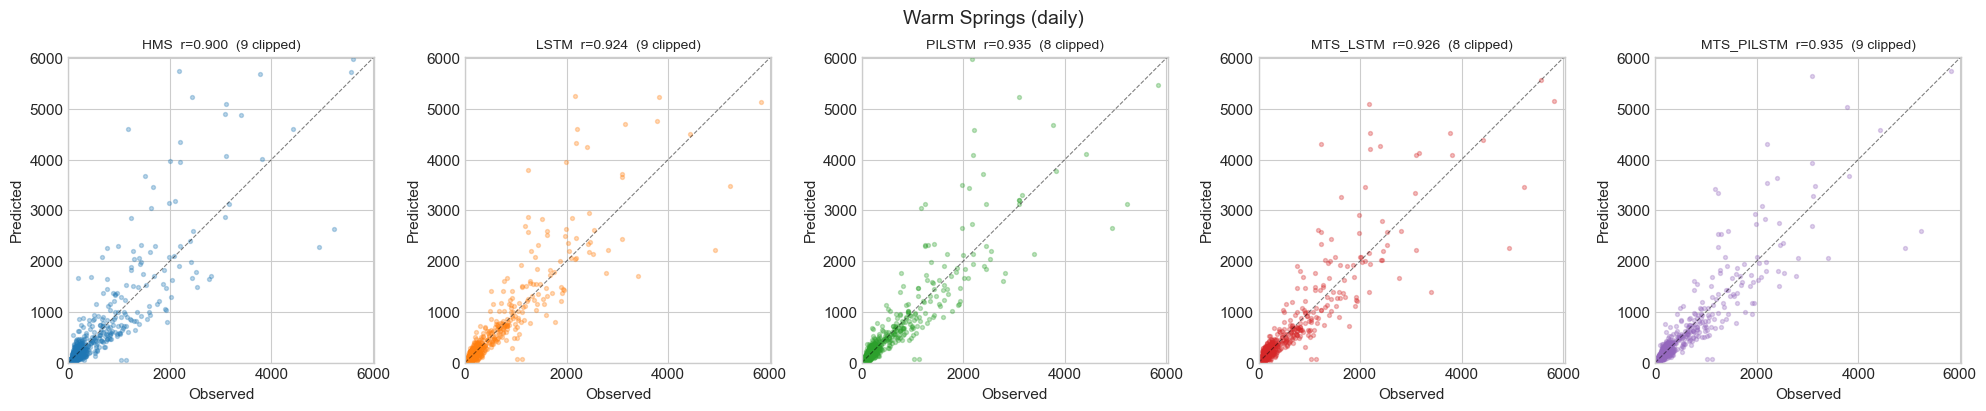

In [45]:
scatter_obs_vs_pred('warm_springs', 'daily')

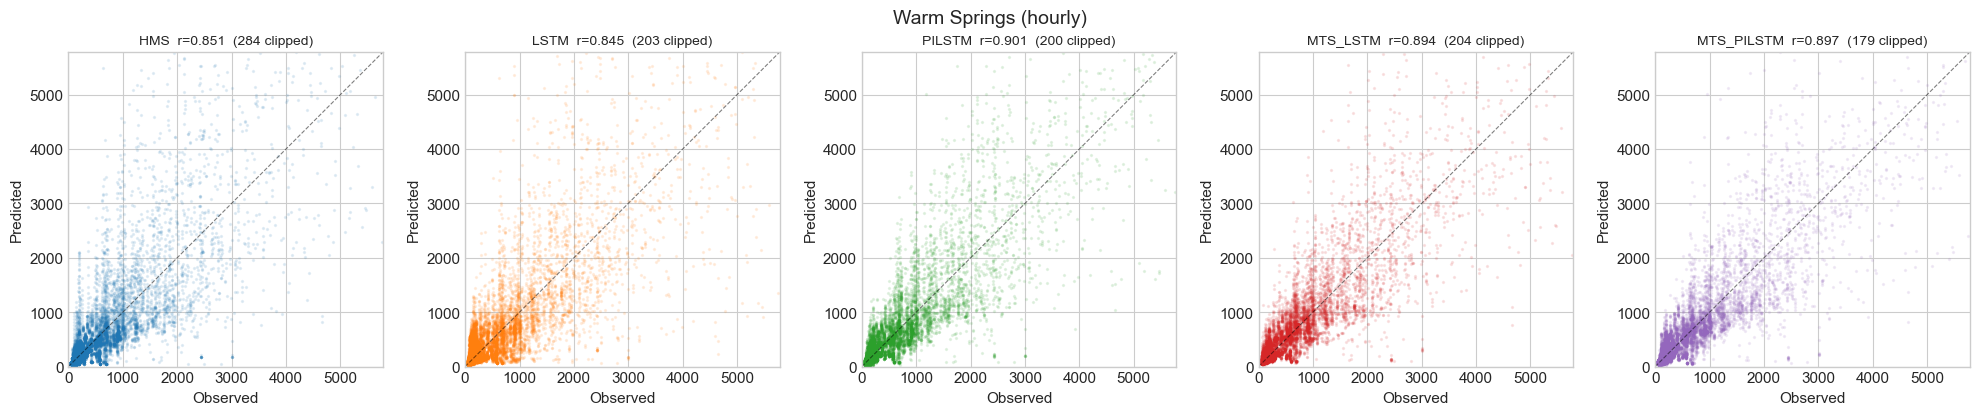

In [46]:
scatter_obs_vs_pred('warm_springs', 'hourly')

#### Flow Duration Curves

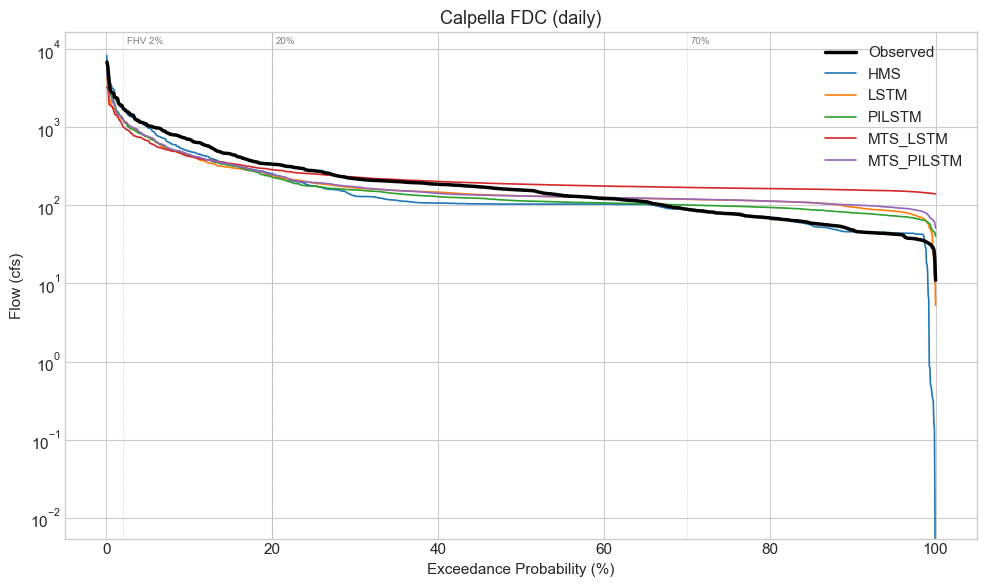

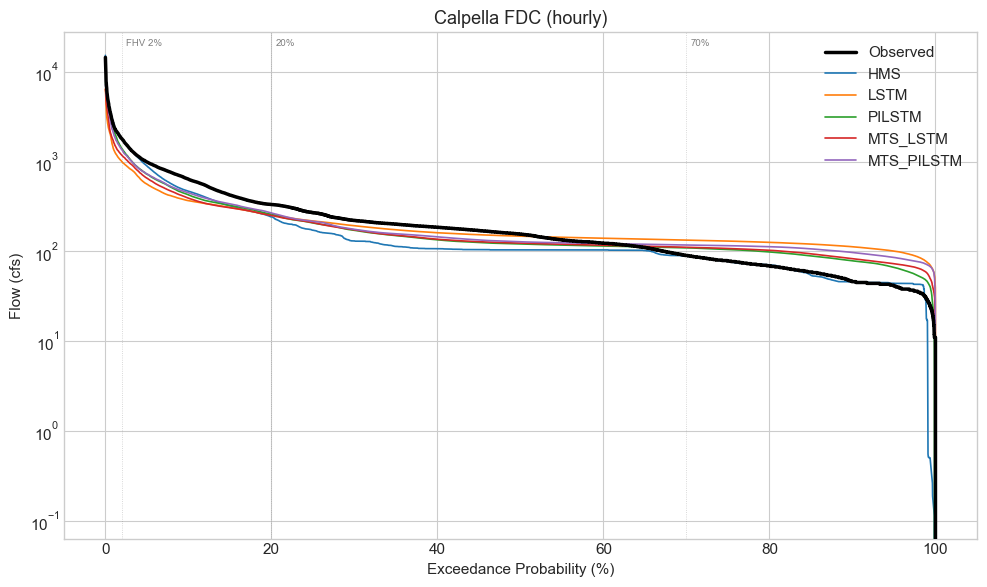

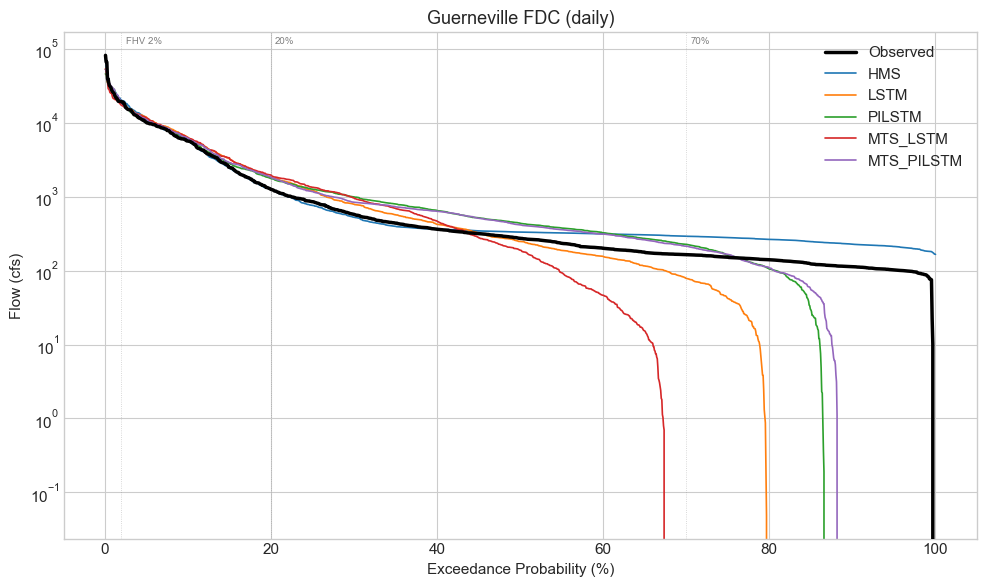

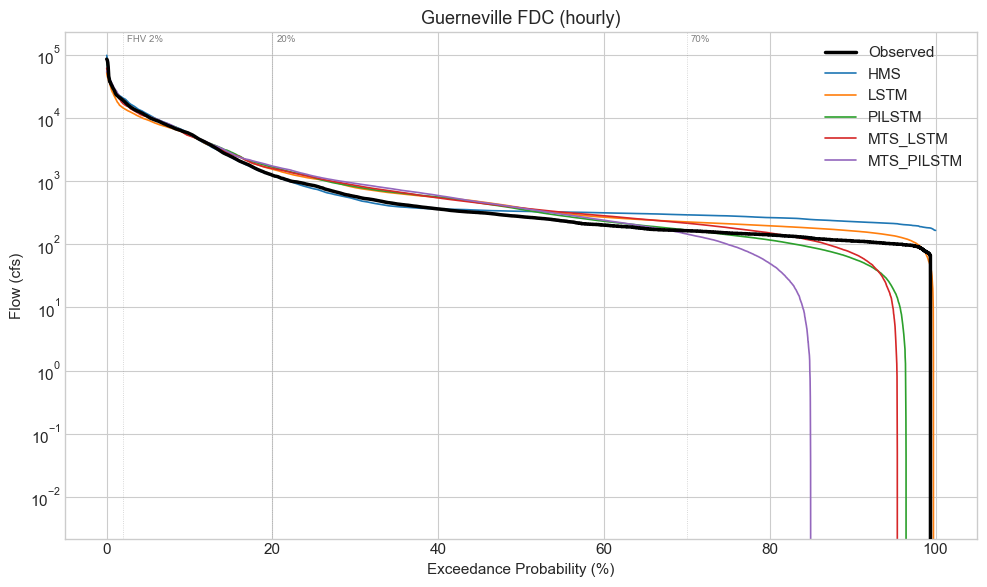

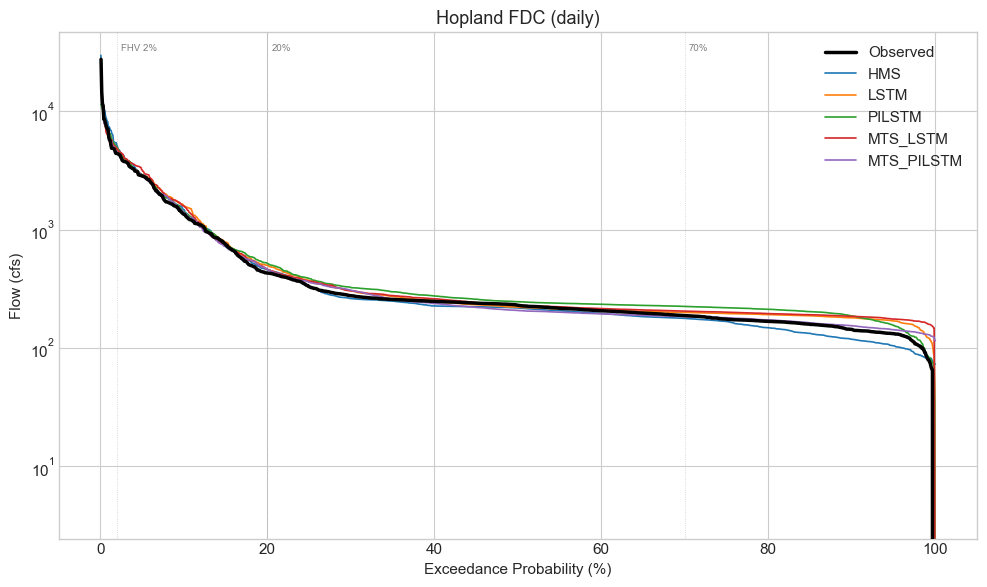

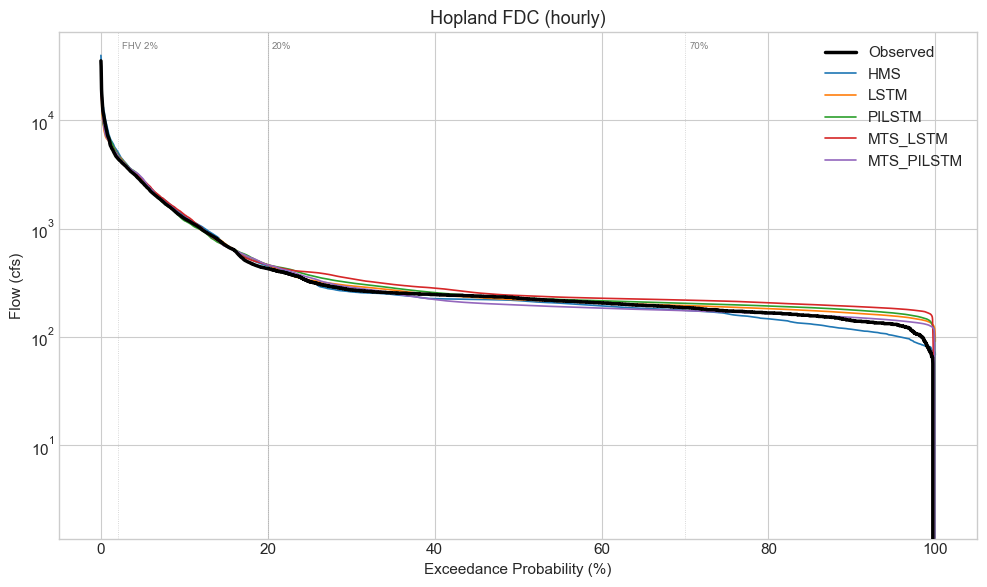

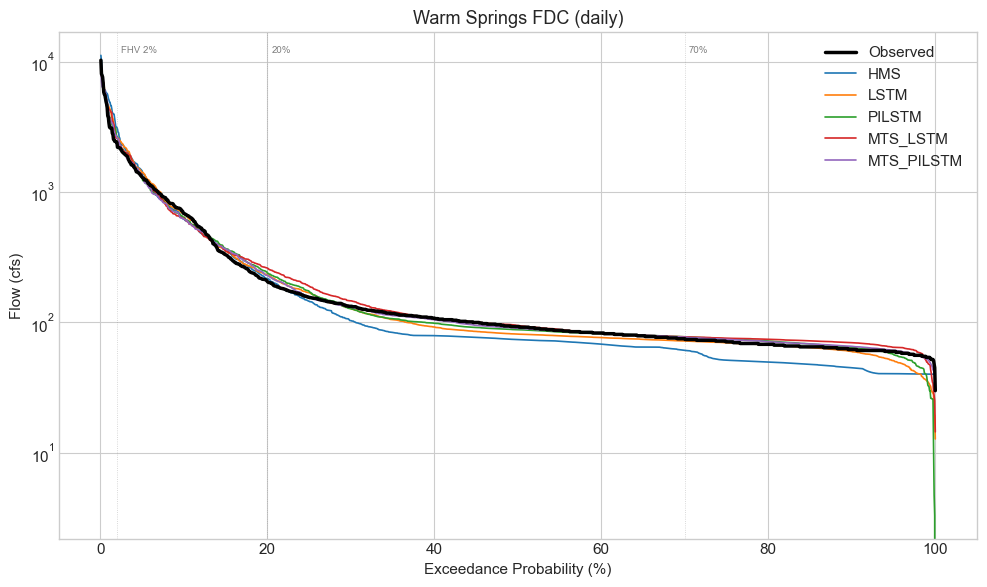

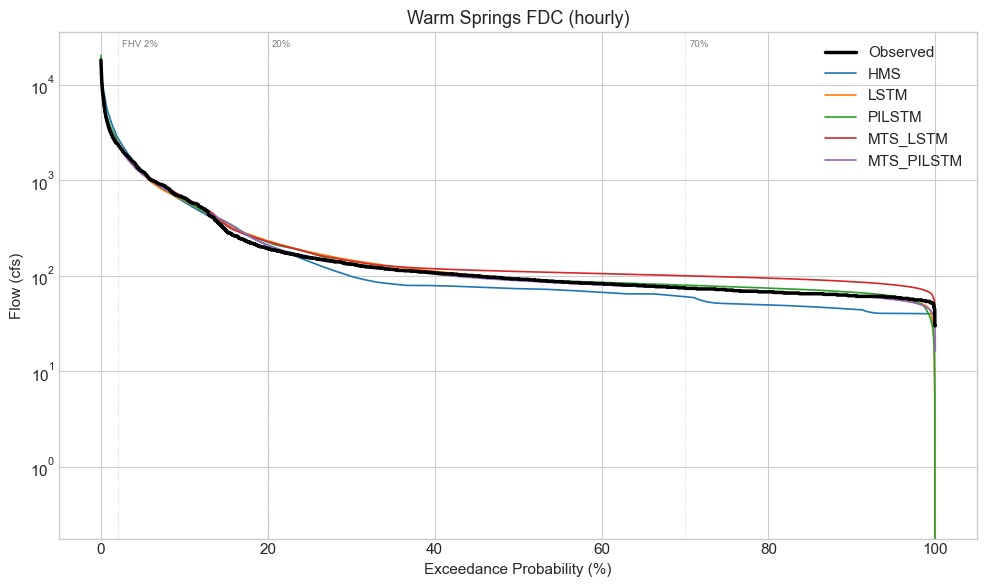

In [47]:
def flow_duration_curve(basin, freq='daily', figsize=(10, 6)):
    df = load_all_models(basin, freq)
    fig, ax = plt.subplots(figsize=figsize)
    for col in ['Observed'] + ALL_MODELS:
        vals = df[col].dropna().sort_values(ascending=False).values
        exceed = np.arange(1, len(vals) + 1) / len(vals) * 100
        kw = {'lw': 2.5, 'color': 'black', 'zorder': 5} if col == 'Observed' else {'lw': 1.2, 'color': MODEL_COLORS[col]}
        ax.plot(exceed, vals, label=col, **kw)
    ax.set_yscale('log')
    ax.set_xlabel('Exceedance Probability (%)')
    ax.set_ylabel('Flow (cfs)')
    ax.set_title(f'{basin.replace("_", " ").title()} FDC ({freq})')
    ax.legend()
    ylim = ax.get_ylim()
    for pct, lbl in [(2, 'FHV 2%'), (20, '20%'), (70, '70%')]:
        ax.axvline(x=pct, color='gray', ls=':', lw=0.6, alpha=0.4)
        ax.text(pct + 0.5, ylim[1] * 0.7, lbl, fontsize=7, color='gray')
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'fdcs' / f'{basin}_{freq}_fdc.png', dpi=300, bbox_inches='tight')
    plt.show()

for basin in BASINS:
    for freq in ['daily', 'hourly']:
        flow_duration_curve(basin, freq)

#### Hydrograph Timeseries — Top Peak Events

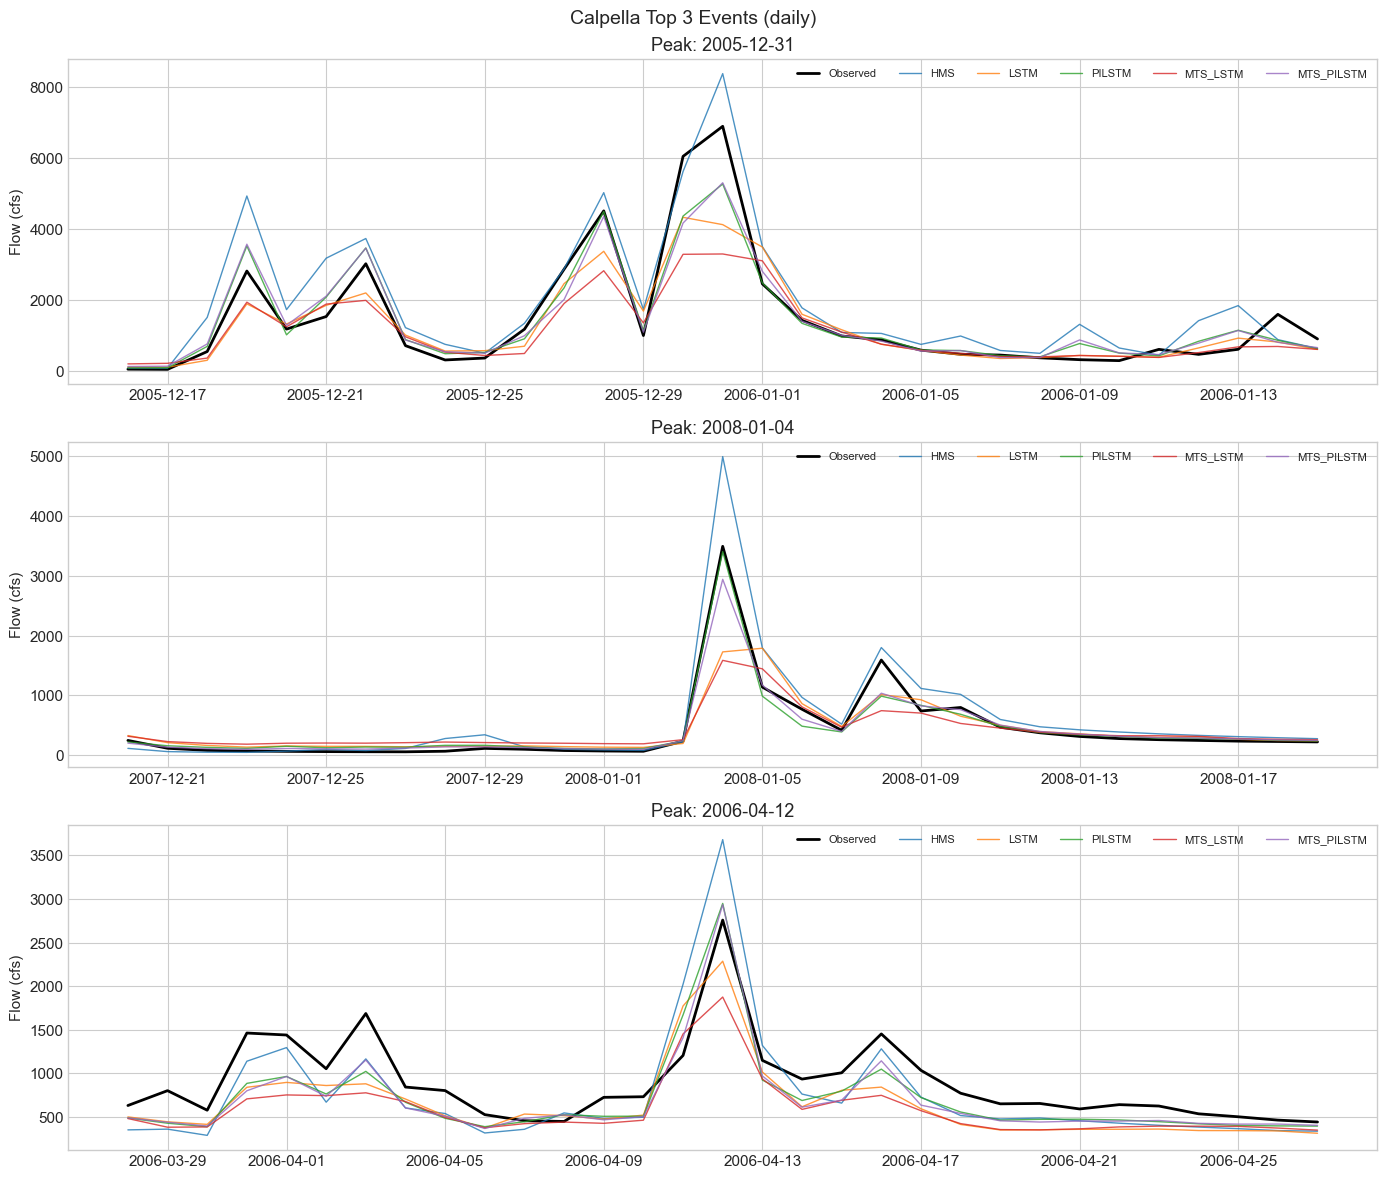

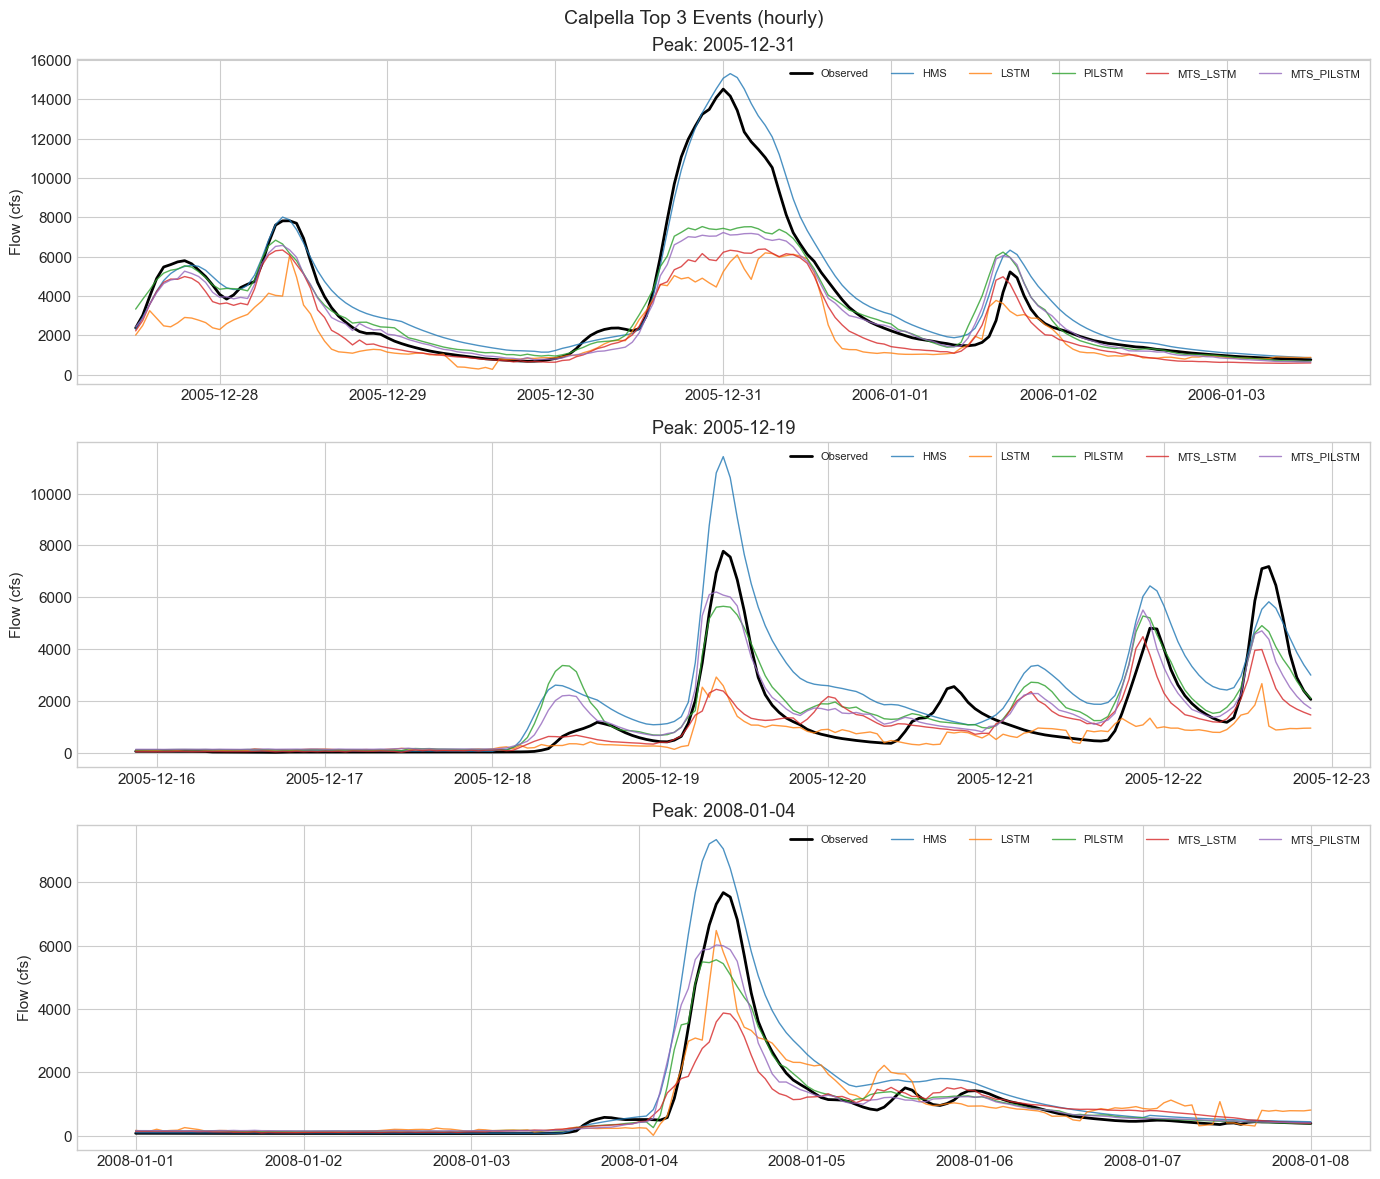

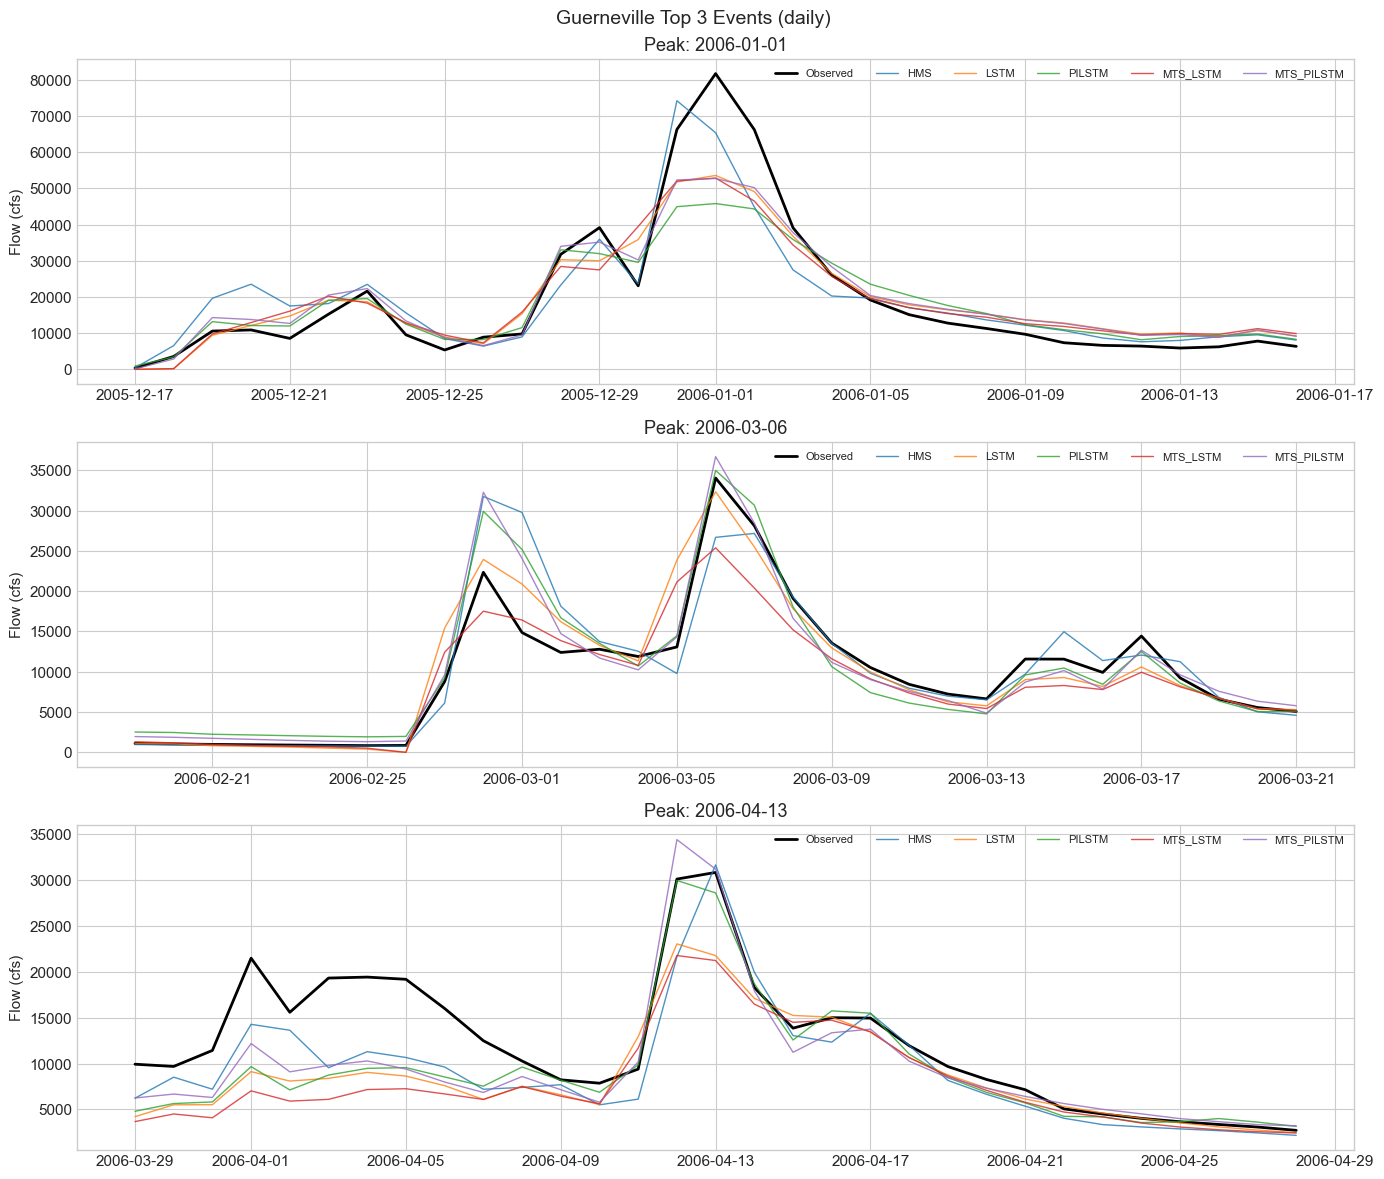

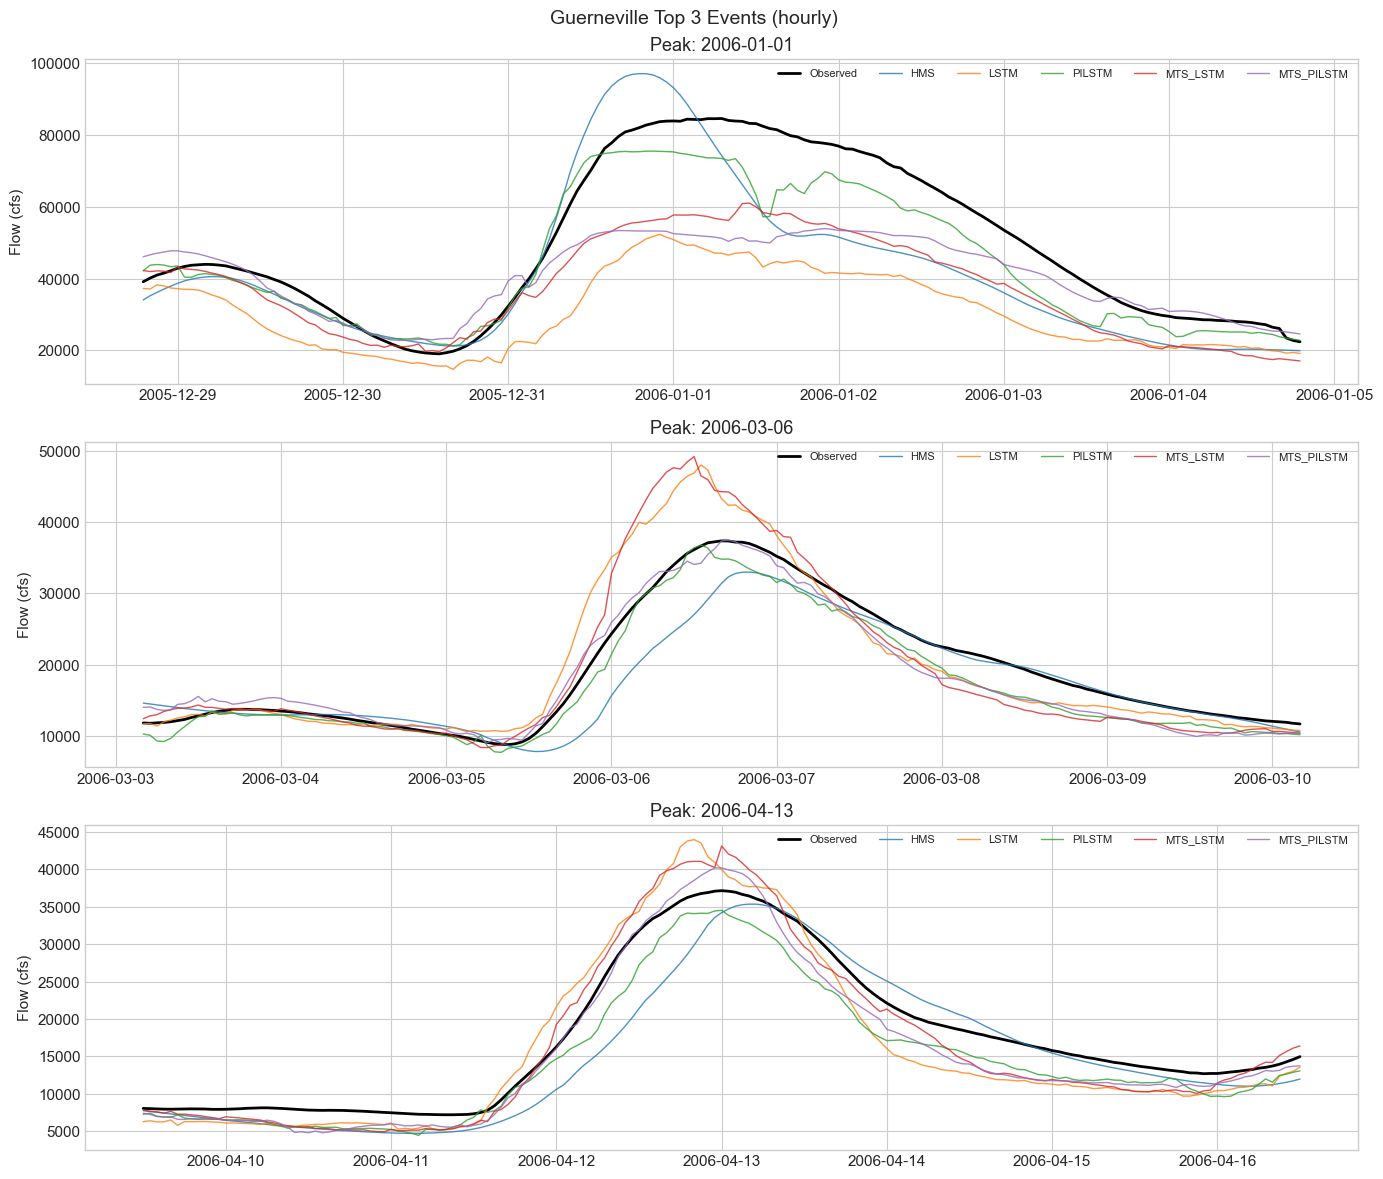

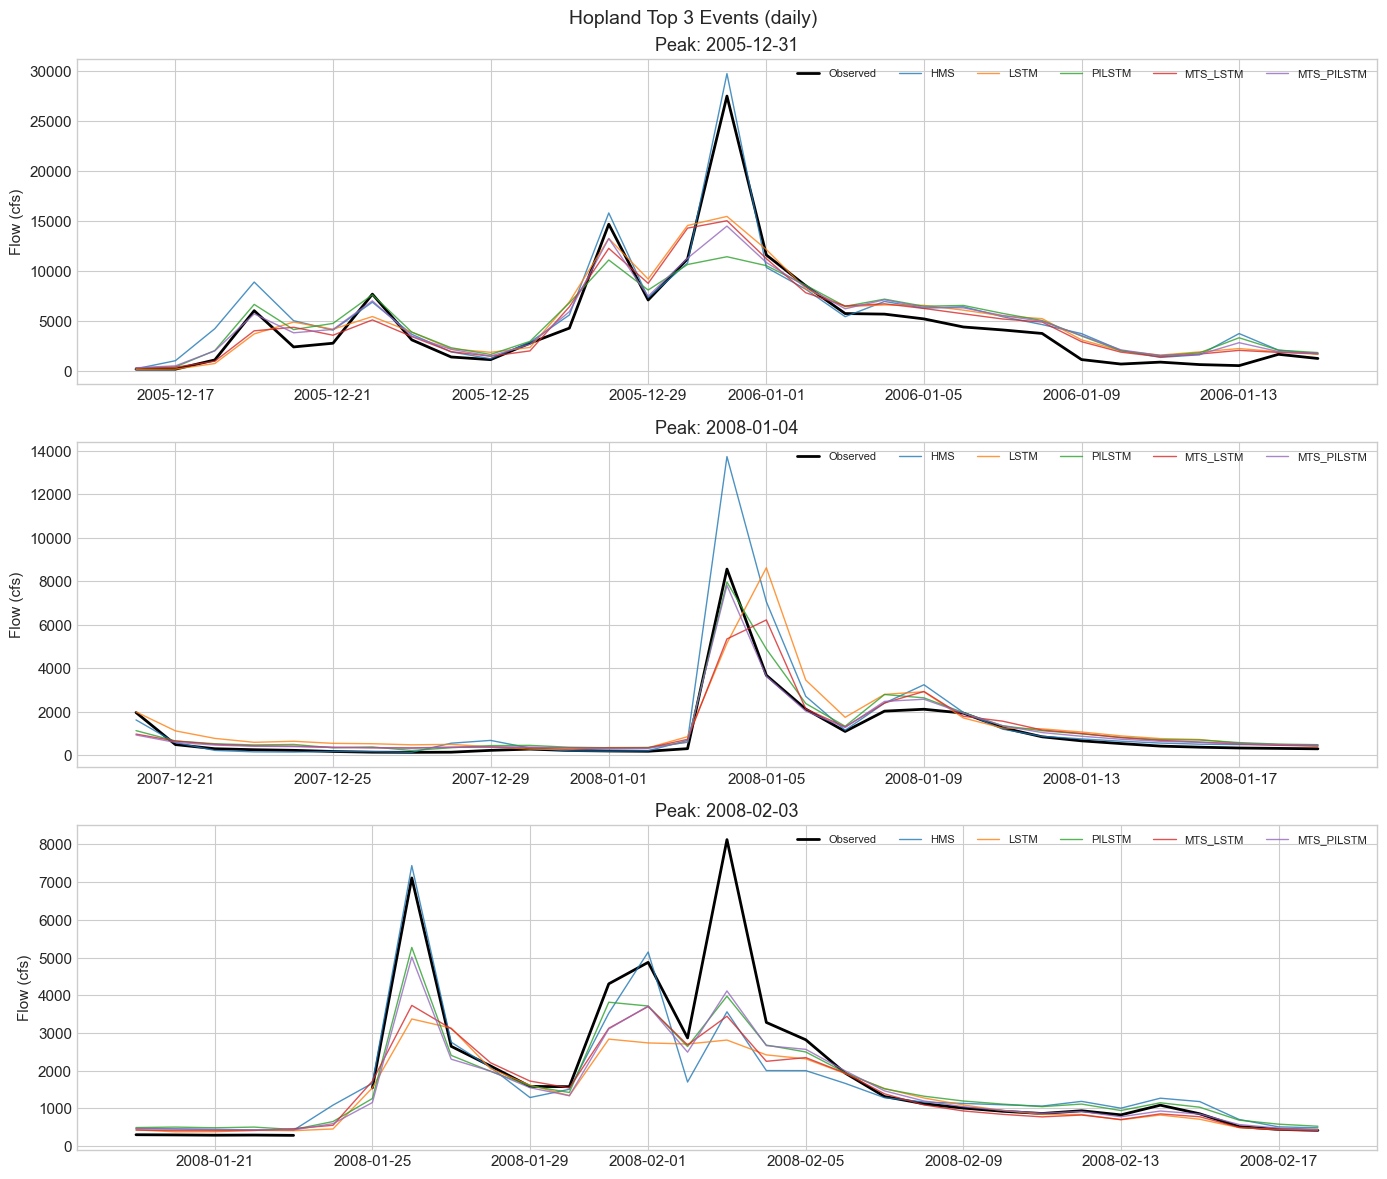

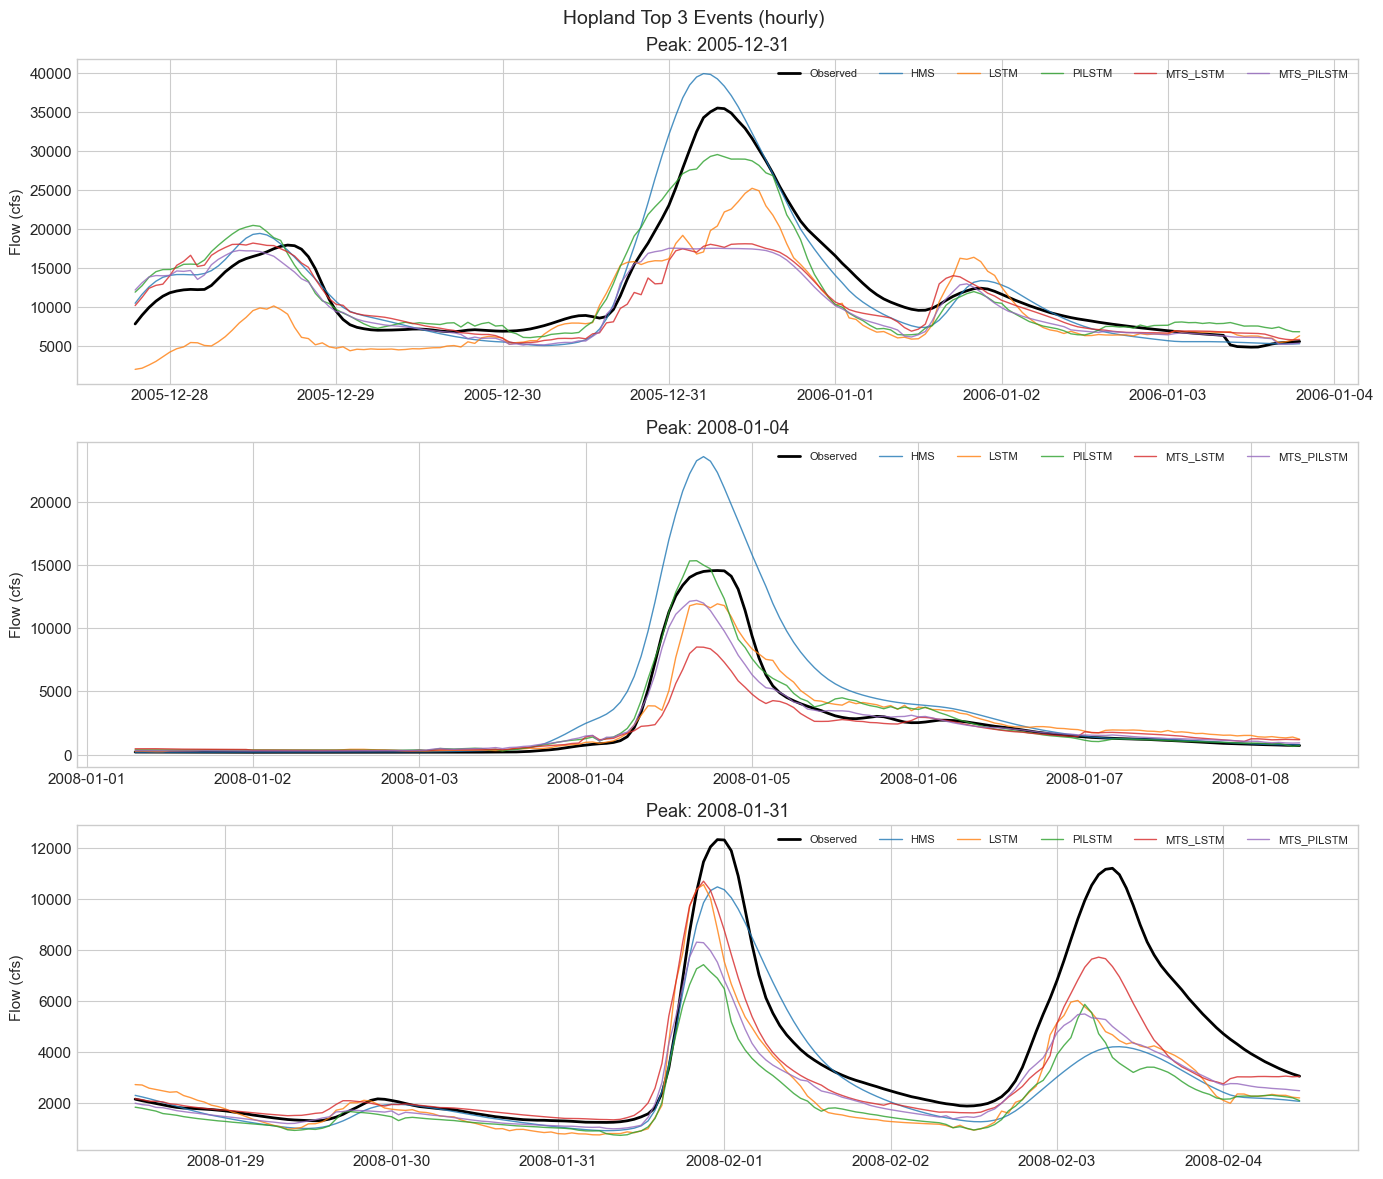

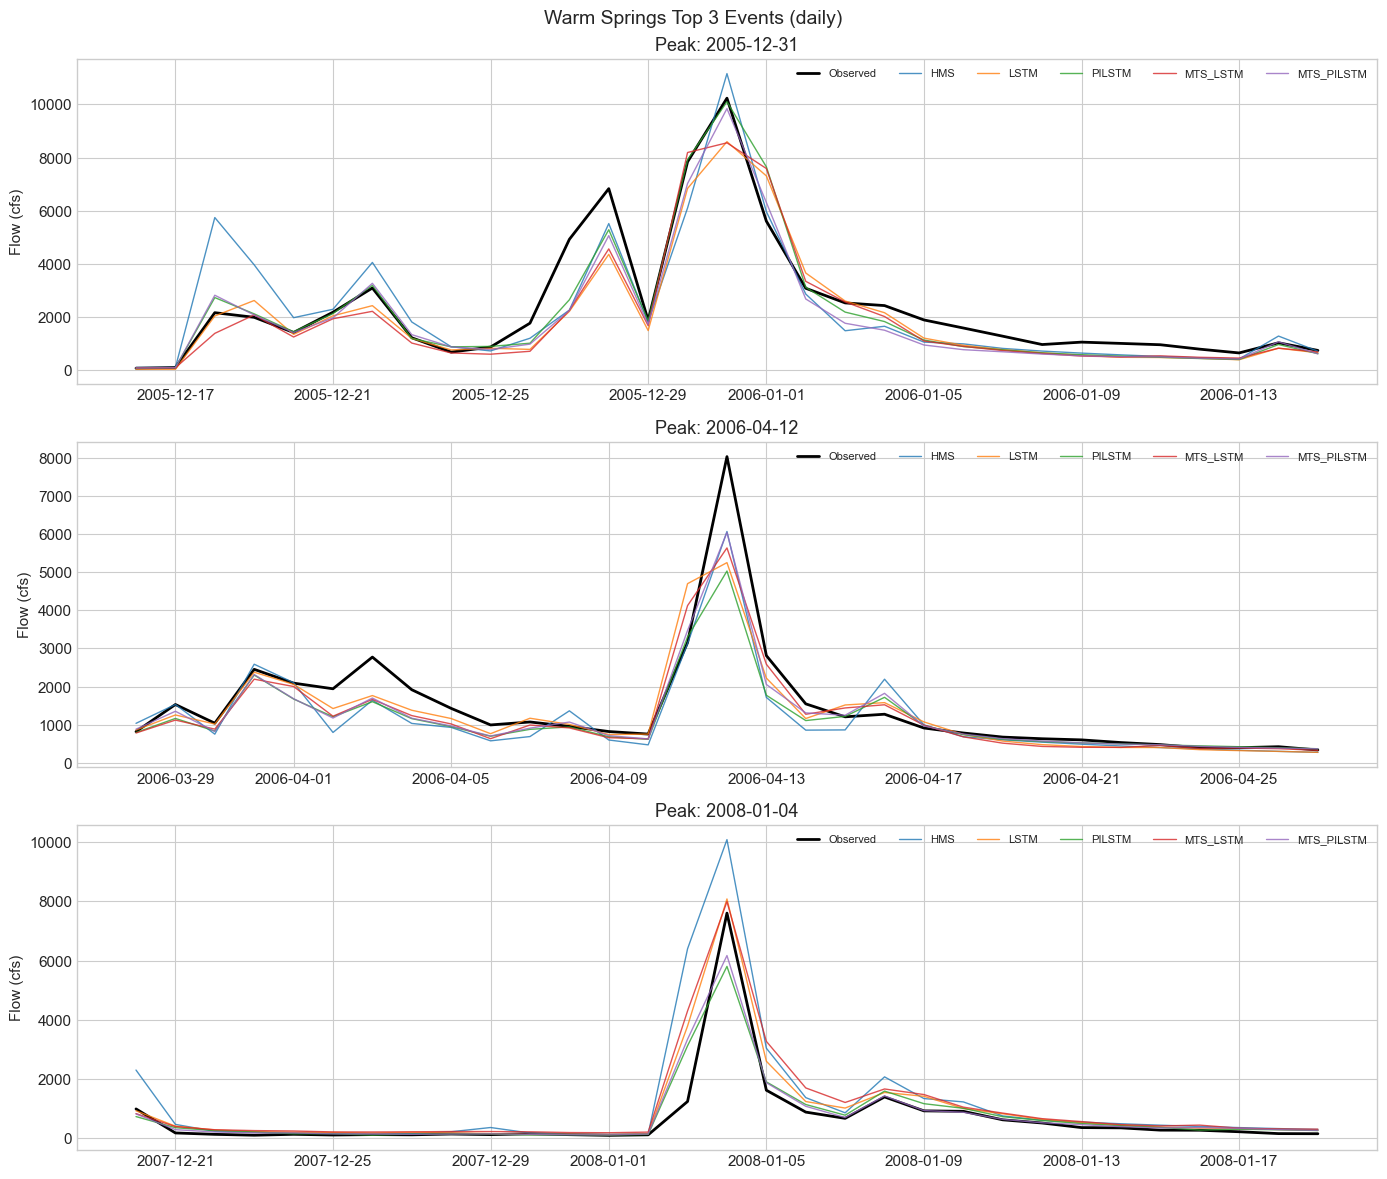

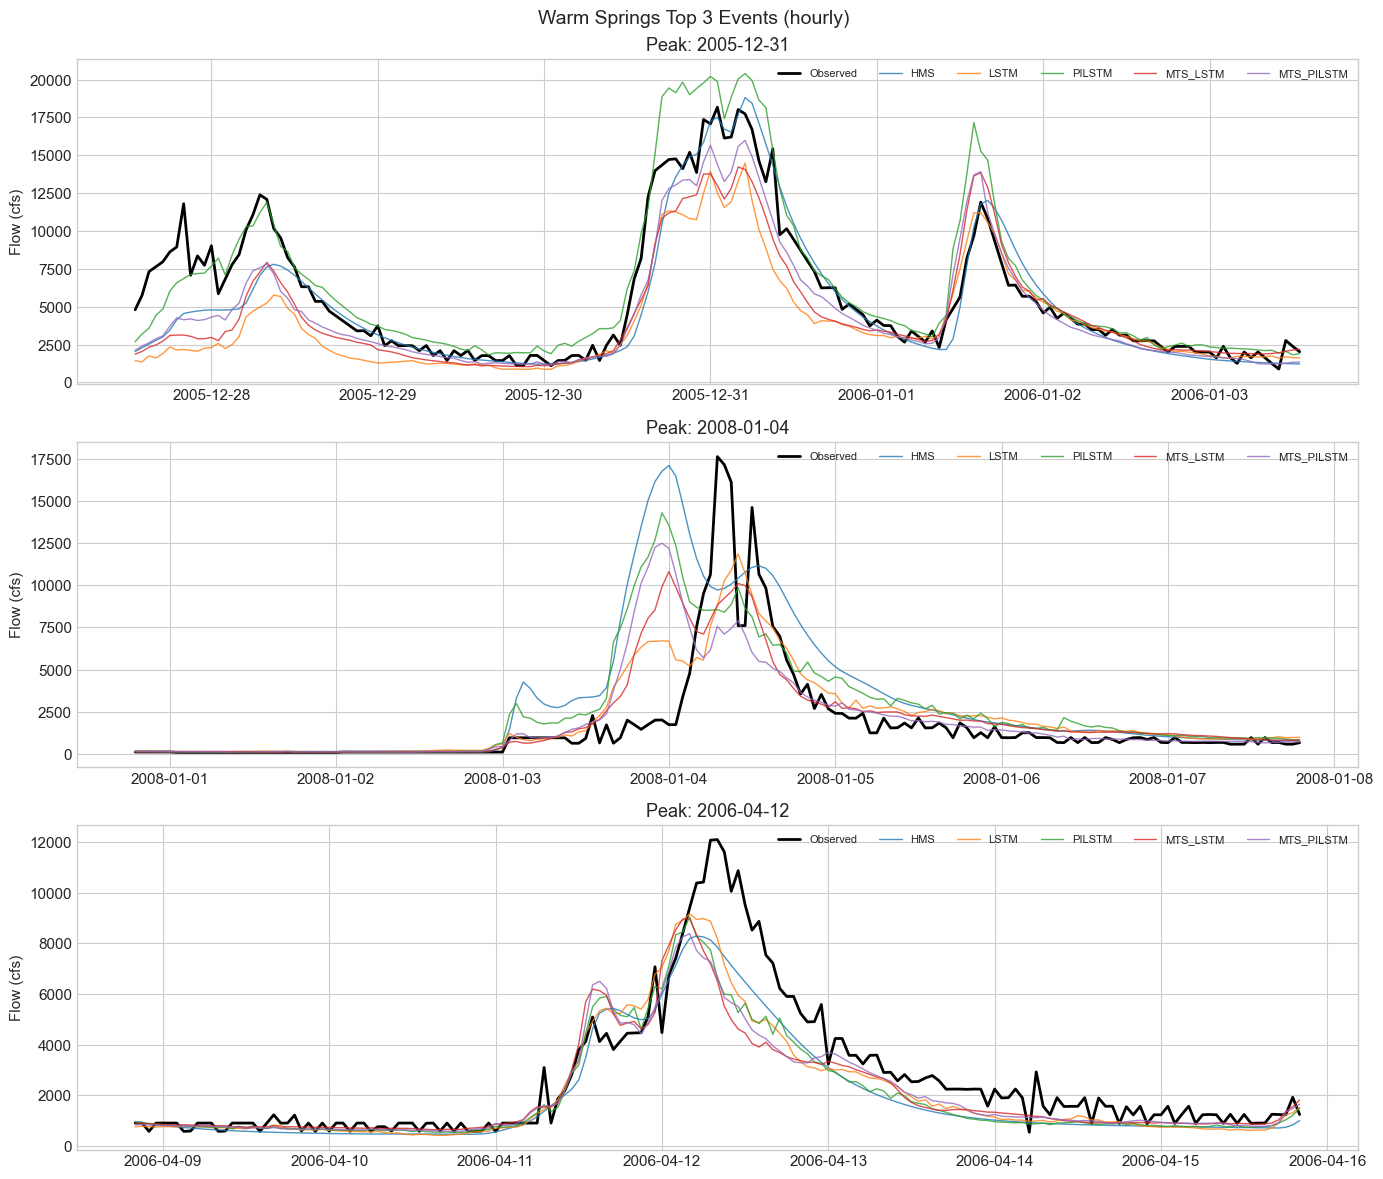

In [48]:
def hydrograph(basin, freq='daily', top_n=3, figsize=(14, 12)):
    df = load_all_models(basin, freq)
    window = pd.Timedelta(days=30 if freq == 'daily' else 7)
    obs = df['Observed'].sort_values(ascending=False)
    peaks = []
    for date in obs.index:
        if not any(abs((date - p).total_seconds()) < window.total_seconds() for p in peaks):
            peaks.append(date)
            if len(peaks) >= top_n:
                break
    fig, axes = plt.subplots(top_n, 1, figsize=figsize, sharex=False)
    if top_n == 1: axes = [axes]
    half = window / 2
    for ax, peak in zip(axes, peaks):
        sub = df.loc[peak - half:peak + half]
        ax.plot(sub.index, sub['Observed'], 'k-', lw=2, label='Observed')
        for model in ALL_MODELS:
            ax.plot(sub.index, sub[model], lw=1, color=MODEL_COLORS[model], alpha=0.8, label=model)
        ax.set_ylabel('Flow (cfs)')
        ax.legend(fontsize=8, ncol=6, loc='upper right')
        ax.set_title(f'Peak: {peak.strftime("%Y-%m-%d")}')
    fig.suptitle(f'{basin.replace("_", " ").title()} Top {top_n} Events ({freq})', fontsize=14)
    plt.tight_layout()
    fig.savefig(FIGURES_DIR / 'hydrographs' / f'{basin}_{freq}_hydrograph.png', dpi=300, bbox_inches='tight')
    plt.show()

for basin in BASINS:
    for freq in ['daily', 'hourly']:
        hydrograph(basin, freq)